## Analysis of the processed dataset

In [1]:
import sys
import os
import numpy as np
import s3fs
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from dotenv import load_dotenv
project_root = '/home/onyxia/work/election_modeling_uhcp'
sys.path.insert(0, project_root)
from src.components.data_processing.data_loader import DataLoader
load_dotenv()

True

In [2]:
os.environ["AWS_ACCESS_KEY_ID"] = 'LUEQJQVXXVT45IX81NRK'
os.environ["AWS_SECRET_ACCESS_KEY"] = 'kRA0FrBvUoHksj+u8V6DOxYvDwHTWGSA5MYr3QKz'
os.environ["AWS_SESSION_TOKEN"] = 'eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJhY2Nlc3NLZXkiOiJMVUVRSlFWWFhWVDQ1SVg4MU5SSyIsImFsbG93ZWQtb3JpZ2lucyI6WyIqIl0sImF1ZCI6WyJtaW5pby1kYXRhbm9kZSIsIm9ueXhpYSIsImFjY291bnQiXSwiYXV0aF90aW1lIjoxNzY5NDQ2OTg4LCJhenAiOiJvbnl4aWEiLCJlbWFpbCI6ImFydGh1ci5tYW5jZWF1QHN0dWRlbnQtY3MuZnIiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwiZXhwIjoxNzcwNTY1NjgzLCJmYW1pbHlfbmFtZSI6Ik1hbmNlYXUiLCJnaXZlbl9uYW1lIjoiQXJ0aHVyIiwiZ3JvdXBzIjpbIlVTRVJfT05ZWElBIl0sImlhdCI6MTc2OTk2MDg4MiwiaXNzIjoiaHR0cHM6Ly9hdXRoLmxhYi5zc3BjbG91ZC5mci9hdXRoL3JlYWxtcy9zc3BjbG91ZCIsImp0aSI6Im9ucnRydDo2MTcxNDU0Ni0wNmM4LTM0ZjQtMmJlNC04OTJjMGJkYmM2NjgiLCJsb2NhbGUiOiJlbiIsIm5hbWUiOiJBcnRodXIgTWFuY2VhdSIsInBvbGljeSI6InN0c29ubHkiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJhcnRodXJtYW5jZWF1IiwicmVhbG1fYWNjZXNzIjp7InJvbGVzIjpbIm9mZmxpbmVfYWNjZXNzIiwidW1hX2F1dGhvcml6YXRpb24iLCJkZWZhdWx0LXJvbGVzLXNzcGNsb3VkIl19LCJyZXNvdXJjZV9hY2Nlc3MiOnsiYWNjb3VudCI6eyJyb2xlcyI6WyJtYW5hZ2UtYWNjb3VudCIsIm1hbmFnZS1hY2NvdW50LWxpbmtzIiwidmlldy1wcm9maWxlIl19fSwicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJ1bWFfYXV0aG9yaXphdGlvbiIsImRlZmF1bHQtcm9sZXMtc3NwY2xvdWQiXSwic2NvcGUiOiJvcGVuaWQgcHJvZmlsZSBncm91cHMgZW1haWwiLCJzaWQiOiIxNGE1ZTU2Zi01ZjQyLTkzYjQtMzNjMy1lMGI2NmZkYzg2MmEiLCJzdWIiOiJiYzc3Yjk3YS1lN2VkLTQ4ZWMtYmQ4Zi1lNzBjYjZhMTYyZGIiLCJ0eXAiOiJCZWFyZXIifQ.JiIC6q8sO0yXN3uCOh13F9qcTJHQoeiKI1XxoUM40-csxqyi2F3uWJeqSA9iEGzWARxsYqrq98b6orxqOn0MBw'
os.environ["AWS_DEFAULT_REGION"] = 'us-east-1'
fs = s3fs.S3FileSystem(
    client_kwargs={'endpoint_url': 'https://'+'minio.lab.sspcloud.fr'},
    key = os.environ["AWS_ACCESS_KEY_ID"], 
    secret = os.environ["AWS_SECRET_ACCESS_KEY"], 
    token = os.environ["AWS_SESSION_TOKEN"])

In [68]:
dataset = DataLoader().load_dataset("s3://arthurmanceau/election_modeling_uhcp/data/derived/processed/data_ppar_pvoteD_pvoteG_pvoteCG_pvoteCD_pvoteC_pvoteTD_pvoteTG_pvoteGCG_pvoteDCD_1958_presidentiel_legislative_20260201_185009.parquet", fs=fs)

2026-02-01 19:06:50.165 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:57 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/derived/processed/data_ppar_pvoteD_pvoteG_pvoteCG_pvoteCD_pvoteC_pvoteTD_pvoteTG_pvoteGCG_pvoteDCD_1958_presidentiel_legislative_20260201_185009.parquet...


2026-02-01 19:06:51.209 | DEBUG    | src.components.data_processing.data_loader:load_dataset:189 - Dataset loaded: (34849, 446)


In [69]:
X = dataset[(dataset['annee']==2022)&(dataset['type']==0)]
assert not X['codecommune'].duplicated().any()

PB — with the previous 

In [84]:
dataset['pvotepreviouspvoteTD'].isna().astype(int).sum()

np.int64(8)

In [71]:
L = [col for col in X.columns if 'pvote' in col]
print(L)
n_blocs = 5+1+2+2
n_elec = 4
assert n_elec * n_blocs - 1 == len(L)
assert np.isclose(
    X[['pvotepvoteD', 'pvotepvoteG', 'pvotepvoteCG', 'pvotepvoteCD', 'pvotepvoteC']].sum(axis=1),
    1.00
).all()
assert np.isclose(
    X[['pvotepvoteTD', 'pvotepvoteTG']].sum(axis=1),
    1.00
).all()
assert np.isclose(
    X[['pvotepvoteDCD', 'pvotepvoteC', 'pvotepvoteGCG']].sum(axis=1),
    1.00
).all()

assert np.isclose(
    X[['pvotepreviouspreviouspvoteD', 'pvotepreviouspreviouspvoteG', 'pvotepreviouspreviouspvoteCG', 'pvotepreviouspreviouspvoteCD', 'pvotepreviouspreviouspvoteC']].dropna().sum(axis=1),
    1.00
).all()
assert np.isclose(
    X[['pvotepreviouspreviouspvoteTD', 'pvotepreviouspreviouspvoteTG']].dropna().sum(axis=1),
    1.00
).all()
assert np.isclose(
    X[['pvotepreviouspreviouspvoteDCD', 'pvotepreviouspreviouspvoteC', 'pvotepreviouspreviouspvoteGCG']].dropna().sum(axis=1),
    1.00
).all()

assert np.isclose(
    X[['pvotepreviouspvoteTD', 'pvotepreviouspvoteTG']].dropna().sum(axis=1),
    1.00
).all()
assert np.isclose(
    X[['pvotepreviouspvoteDCD', 'pvotepreviouspvoteC', 'pvotepreviouspvoteGCG']].dropna().sum(axis=1),
    1.00
).all()
assert np.isclose(
    X[['pvotepreviouspvoteD', 'pvotepreviouspvoteG', 'pvotepreviouspvoteCG', 'pvotepreviouspvoteCD', 'pvotepreviouspvoteC']].dropna().sum(axis=1),
    1.00
).all()

['pvoteppar', 'pvotepvoteD', 'pvotepvoteG', 'pvotepvoteCG', 'pvotepvoteCD', 'pvotepvoteC', 'pvotepvoteTD', 'pvotepvoteTG', 'pvotepvoteGCG', 'pvotepvoteDCD', 'pvotepreviousppar', 'pvotepreviouspreviousppar', 'pvotepreviouspvoteD', 'pvotepreviouspreviouspvoteD', 'pvotepreviouspvoteG', 'pvotepreviouspreviouspvoteG', 'pvotepreviouspvoteCG', 'pvotepreviouspreviouspvoteCG', 'pvotepreviouspvoteCD', 'pvotepreviouspreviouspvoteCD', 'pvotepreviouspvoteC', 'pvotepreviouspreviouspvoteC', 'pvotepreviouspvoteTD', 'pvotepreviouspreviouspvoteTD', 'pvotepreviouspvoteTG', 'pvotepreviouspreviouspvoteTG', 'pvotepreviouspvoteGCG', 'pvotepreviouspreviouspvoteGCG', 'pvotepreviouspvoteDCD', 'pvotepreviouspreviouspvoteDCD', 'poll_pvoteD', 'poll_pvoteG', 'poll_pvoteCG', 'poll_pvoteCD', 'poll_pvoteC', 'poll_pvoteTD', 'poll_pvoteTG', 'poll_pvoteGCG', 'poll_pvoteDCD']


In [72]:
X['inscrits'].sum() # 48 803 175 

np.float64(45338356.0)

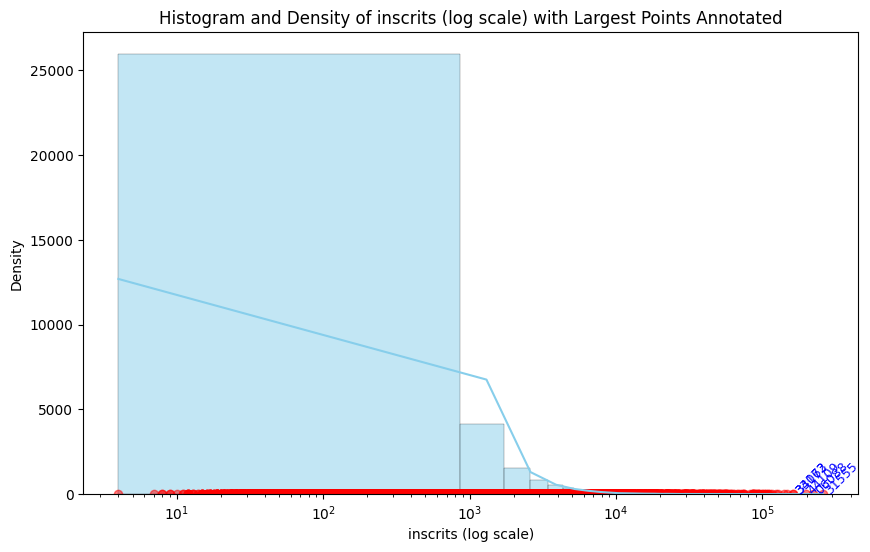

In [73]:
plt.figure(figsize=(10, 6))

sns.histplot(X['inscrits'], kde=True, color='skyblue', bins=300)
plt.scatter(X['inscrits'], [0.01]*len(X), alpha=0.5, color='red')

top_n = 5
largest_indices = X['inscrits'].nlargest(top_n).index
for idx in largest_indices:
    plt.text(X['inscrits'][idx], 0.02, str(X['codecommune'][idx]), rotation=45, fontsize=9, color='blue')

plt.xscale('log')  # Logarithmic scale for x-axis
plt.xlabel('inscrits (log scale)')
plt.ylabel('Density')
plt.title('Histogram and Density of inscrits (log scale) with Largest Points Annotated')
plt.show()

In [74]:
features = [col for col in X.columns if '/' in col]
family_dict = defaultdict(list)
for col in features:
    family = col.split('/')[0]
    family_dict[family].append(col)

In [75]:
nan_cols = X.columns[X.isna().all()]
print(list(nan_cols))

[]


In [76]:
dfc = DataLoader.load_dataset("s3://arthurmanceau/election_modeling_uhcp/data/derived/cache/dfc_cached.parquet")

2026-02-01 19:07:16.433 | DEBUG    | src.components.data_processing.data_loader:_read_parquet:57 - Loading dataset from s3://arthurmanceau/election_modeling_uhcp/data/derived/cache/dfc_cached.parquet...


2026-02-01 19:07:58.841 | DEBUG    | src.components.data_processing.data_loader:load_dataset:189 - Dataset loaded: (38145, 31557)


In [12]:
dfc.loc[dfc['codecommune'] == '69123', 'agesexcommunes/poph60p2022']

30068    42958.0
Name: agesexcommunes/poph60p2022, dtype: float64

In [24]:
dfc.columns

Index(['codecommune', 'dep', 'agesexcommunes/poph0141962',
       'agesexcommunes/poph15391962', 'agesexcommunes/poph40591962',
       'agesexcommunes/poph60p1962', 'agesexcommunes/popf0141962',
       'agesexcommunes/popf15391962', 'agesexcommunes/popf40591962',
       'agesexcommunes/popf60p1962',
       ...
       'popdepartements/popcoma2013', 'popdepartements/popcoma2014',
       'popdepartements/popcoma2015', 'popdepartements/popcoma2016',
       'popdepartements/popcoma2017', 'popdepartements/popcoma2018',
       'popdepartements/popcoma2019', 'popdepartements/popcoma2020',
       'popdepartements/popcoma2021', 'popdepartements/popcoma2022'],
      dtype='object', length=31557)

In [34]:
dfc.loc[dfc['codecommune'] == '76095', ['agesexcommunes/propf40592022', 'agesexcommunes/propf60p2022']]

,agesexcommunes/propf40592022,agesexcommunes/propf60p2022
32458,NaN,NaN


In [22]:
X.loc[X['codecommune']=='01019', ['agesexcommunes/propf4059', 'agesexcommunes/propf60p']]

,agesexcommunes/propf4059,agesexcommunes/propf60p
70705,NaN,0.269231


In [44]:
X.loc[X['agesexcommunes/prop4059'].isna(), ['codecommune', 'inscrits', 'agesexcommunes/prop4059']]['codecommune'].to_list()

['13201',
 '13202',
 '13203',
 '13204',
 '13205',
 '13206',
 '13207',
 '13208',
 '13209',
 '13210',
 '13211',
 '13212',
 '13213',
 '13214',
 '13215',
 '13216',
 '14666',
 '26030',
 '26274',
 '27058',
 '31127',
 '54310',
 '55138',
 '55394',
 '57470',
 '65134',
 '69381',
 '69382',
 '69383',
 '69384',
 '69385',
 '69386',
 '69387',
 '69388',
 '69389',
 '76095',
 '76601']

In [79]:
X.loc[X["empfoncommunes/con"].isna(), ['codecommune', 'inscrits', 'empfoncommunes/con']]

,codecommune,inscrits,empfoncommunes/con
4881,14666,1391.0,NaN
9381,27058,1402.0,NaN


In [50]:
L = ['13201',
 '13202',
 '13203',
 '13204',
 '13205',
 '13206',
 '13207',
 '13208',
 '13209',
 '13210',
 '13211',
 '13212',
 '13213',
 '13214',
 '13215',
 '13216']
nan_cols_in_L = X.loc[X['codecommune'].isin(L)].isna().all()
cols_all_nan_in_L = X.columns[nan_cols_in_L]
L2 = set(cols_all_nan_in_L)

In [51]:
nan_cols_in_L = dataset.loc[dataset['codecommune'].isin(L)].isna().all()
cols_all_nan_in_L = dataset.columns[nan_cols_in_L]
L1= set(cols_all_nan_in_L)

In [62]:
Lm = [el + '2022' for el in list(L2)]

In [67]:
lp = list(set(Lm).intersection(dfc.columns))
dfc.loc[dfc['codecommune']=='13055', lp]

,cspcommunes/cadr2022,cspcommunes/peraind2022,diplomescommunes/psup2022,cspcommunes/paind2022,agesexdepartements/propf15392022,cspcommunes/pagri2022,diplomescommunes/nodipf2022,diplomescommunes/perbac2022,agesexcommunes/propf40592022,cspcommunes/ouvr2022,...,pibcommunes/pop2022,diplomescommunes/suph2022,popcommunes/peragglo2022,popcommunesvbbm/vbbmpauvresriches2022,cspcommunes/perpint2022,agesexcommunes/poph0142022,cspcommunes/empl2022,basesfiscalescommunes/pop2022,agesexdepartements/age2022,cspcommunes/aica2022
4714,53403.0,0.554887,0.369707,0.064924,0.508304,0.00028,145959.0,0.605946,0.520982,41330.0,...,875791.0,98795.0,0.806708,7.0,0.498428,83685.0,80907.0,878298.0,41.839598,70351.0


In [53]:
L2 - L1

{'naticommunes/etraeuro',
 'naticommunes/etranalg',
 'naticommunes/etraxeur',
 'pibdepartements/emploi',
 'pvotepreviouspreviousppar',
 'pvotepreviouspreviouspvoteC',
 'pvotepreviouspreviouspvoteCD',
 'pvotepreviouspreviouspvoteCG',
 'pvotepreviouspreviouspvoteD',
 'pvotepreviouspreviouspvoteDCD',
 'pvotepreviouspreviouspvoteG',
 'pvotepreviouspreviouspvoteGCG',
 'pvotepreviouspreviouspvoteTD',
 'pvotepreviouspreviouspvoteTG'}

In [77]:
for family, cols in family_dict.items():
    cols_ = list(set(cols)- set(nan_cols))
    print(X[cols_].isna().astype(int).sum())

agesexcommunes/age             12
agesexcommunes/perpropf         0
agesexcommunes/prop4059        12
agesexcommunes/agef             0
agesexcommunes/propf           12
agesexcommunes/popf014          0
agesexcommunes/popf             0
agesexcommunes/propf1539      973
agesexcommunes/popf4059         0
agesexcommunes/perprop014       0
agesexcommunes/propf60p       490
agesexcommunes/propf4059      847
agesexcommunes/poph1539         0
agesexcommunes/poph4059         0
agesexcommunes/propf014      1527
agesexcommunes/pop              0
agesexcommunes/popf1539         0
agesexcommunes/prop60p         12
agesexcommunes/perprop60p       0
agesexcommunes/poph014          0
agesexcommunes/perage           0
agesexcommunes/ageh             0
agesexcommunes/prop1539        12
agesexcommunes/poph60p          0
agesexcommunes/prop014         12
agesexcommunes/poph             0
agesexcommunes/popf60p          0
dtype: int64
agesexdepartements/popf1539     0
agesexdepartements/prop60p      0
a

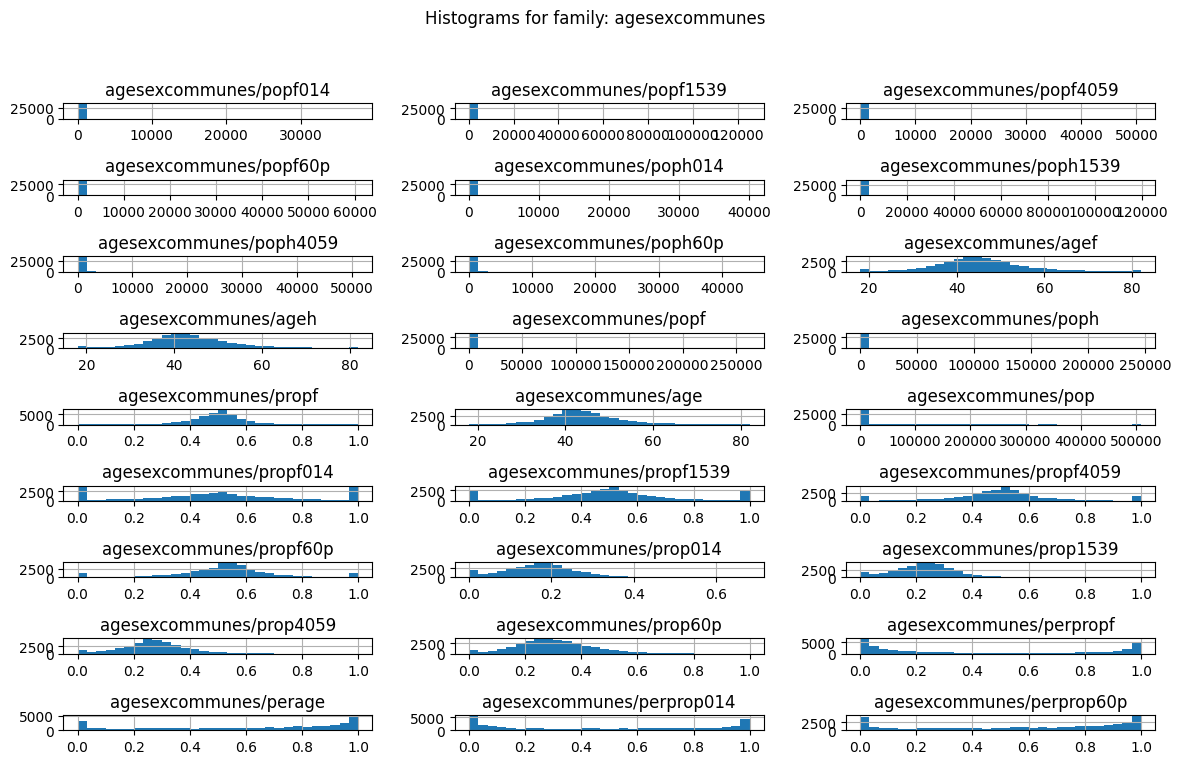

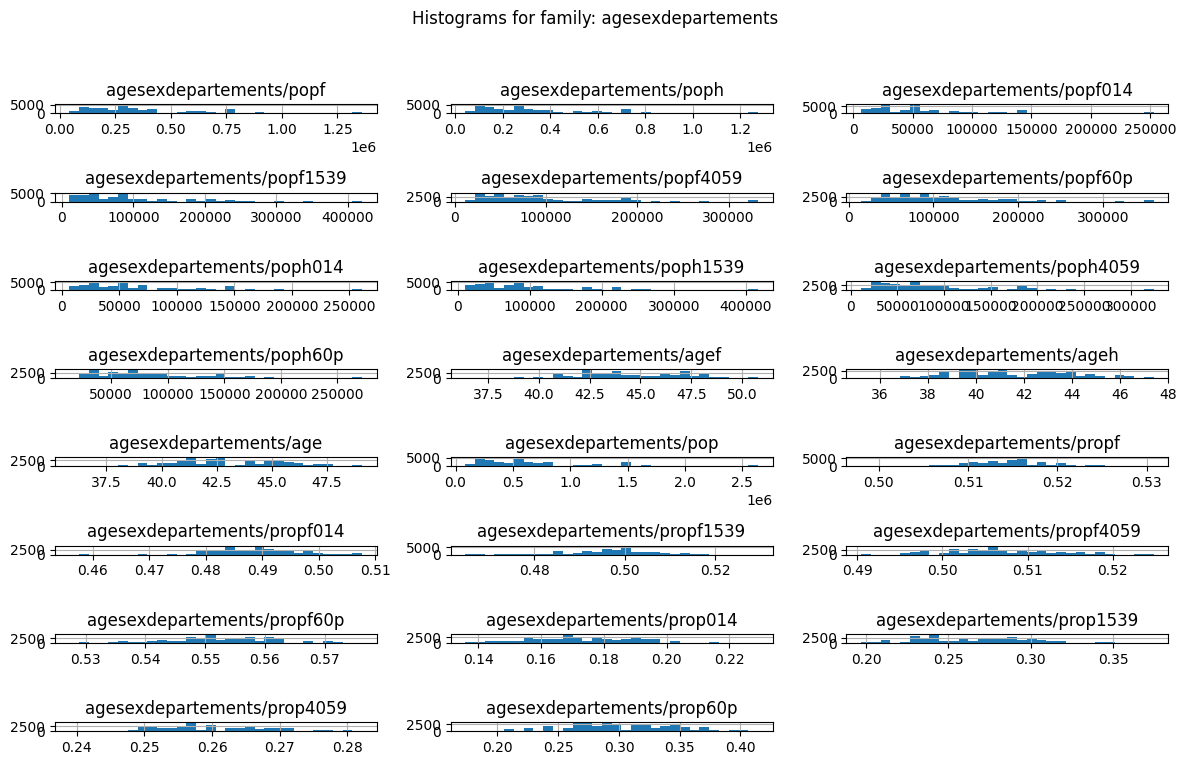

/tmp/ipykernel_2295/1155977053.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


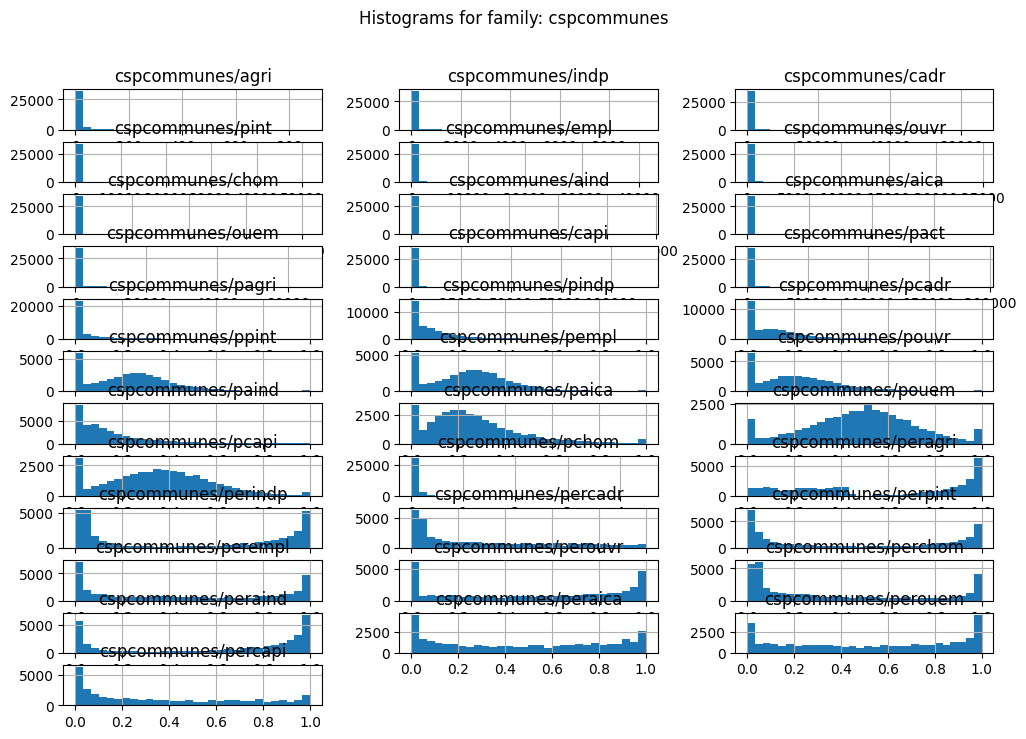

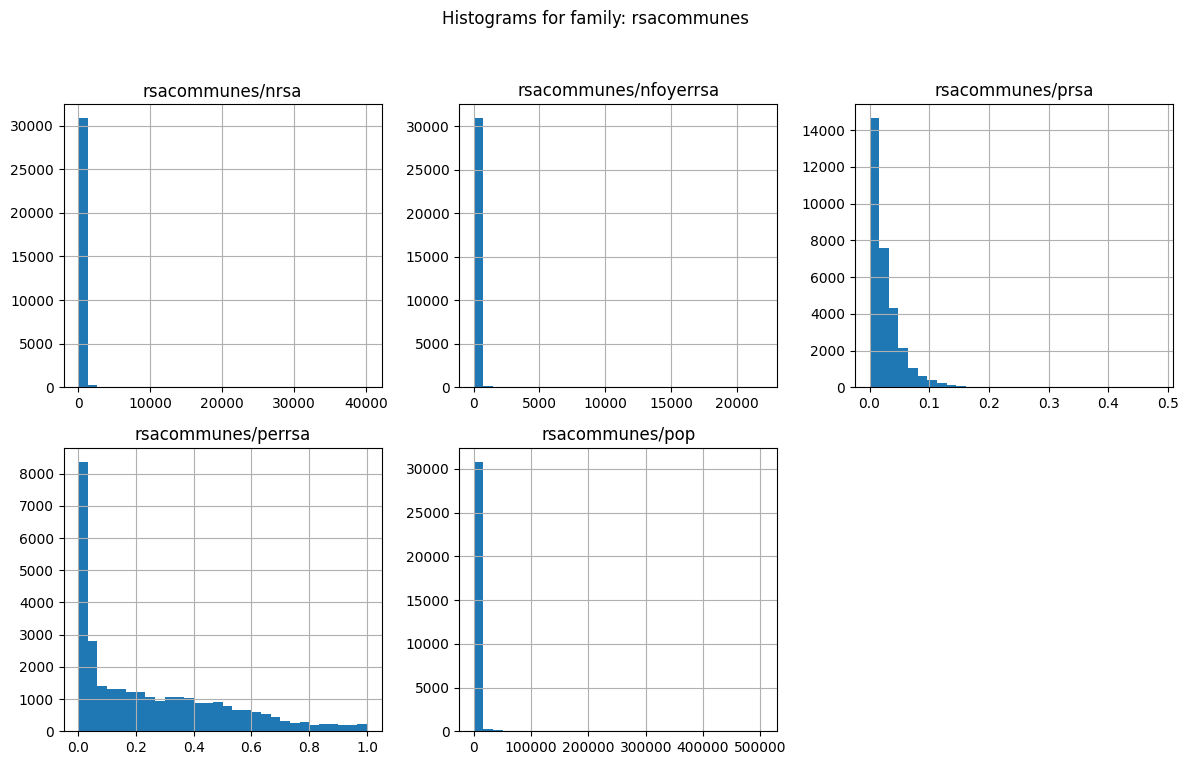

/tmp/ipykernel_2295/1155977053.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


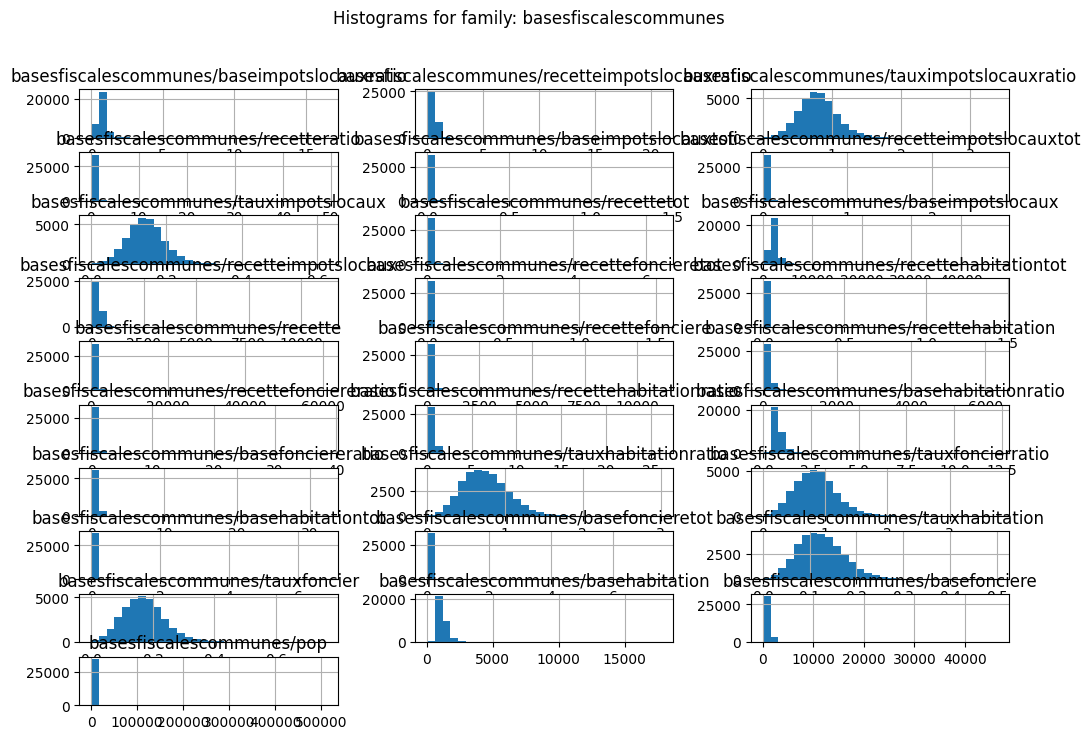

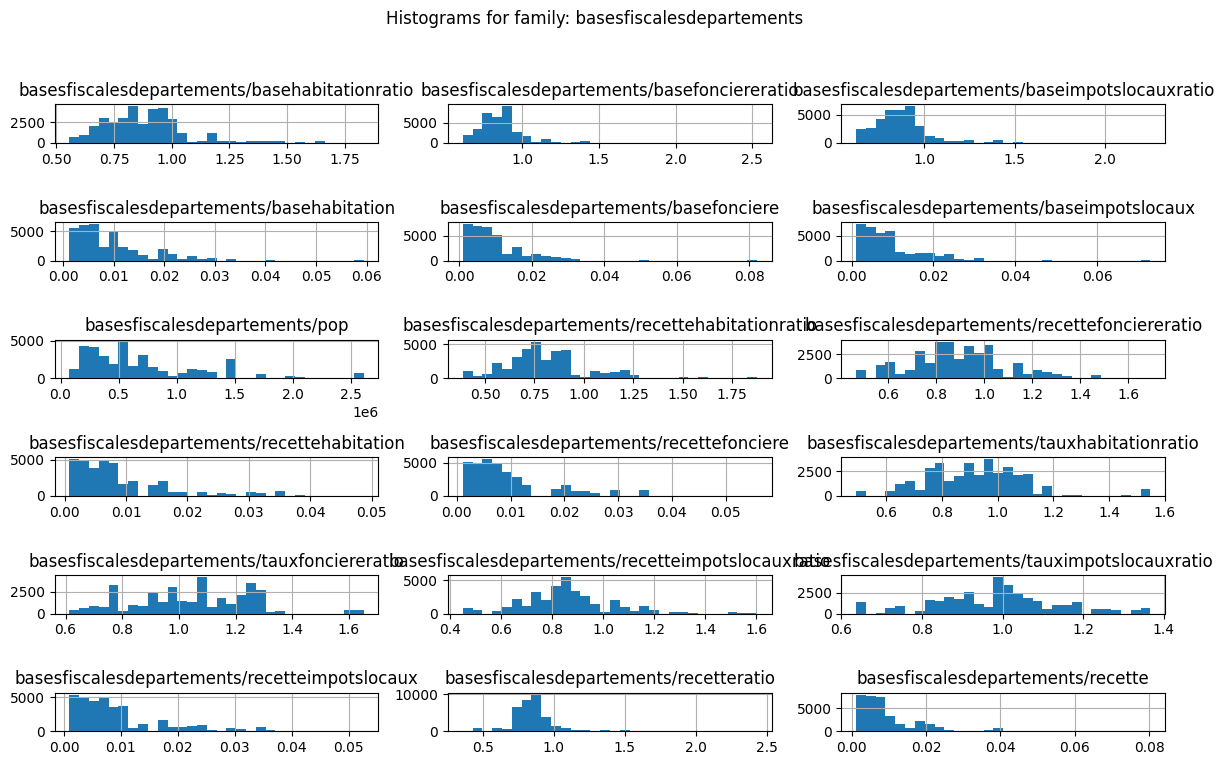

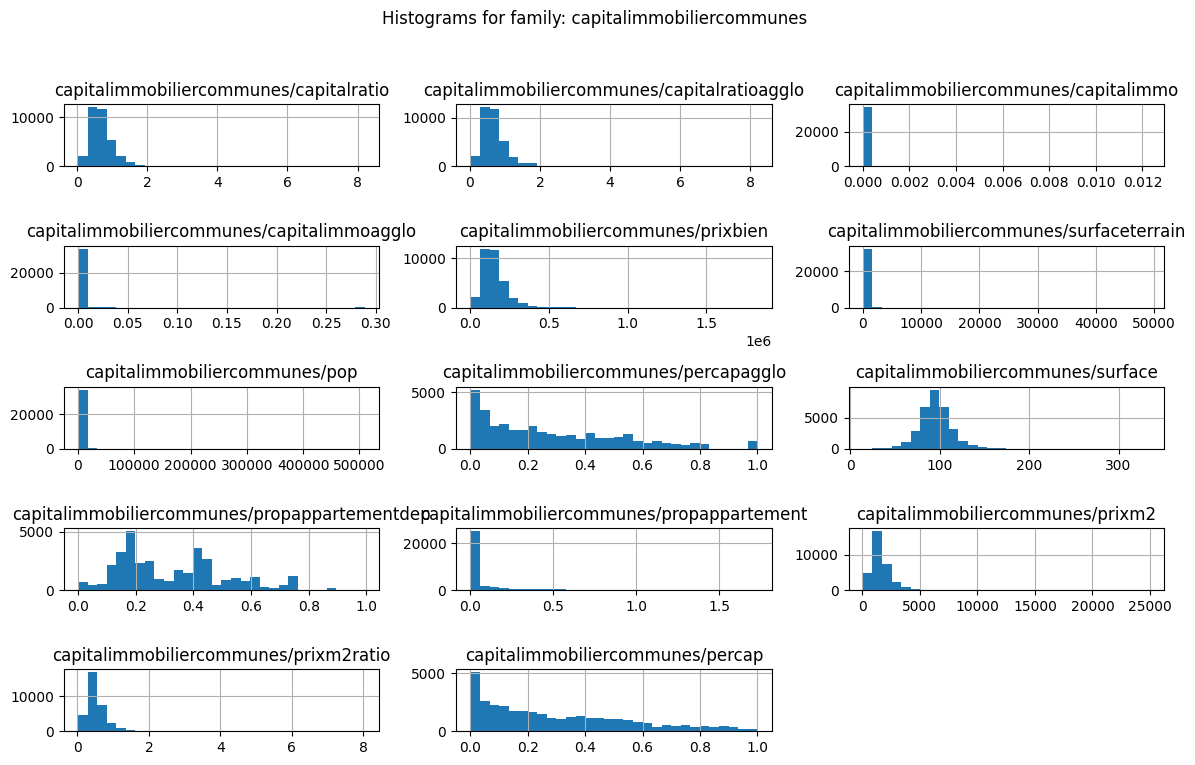

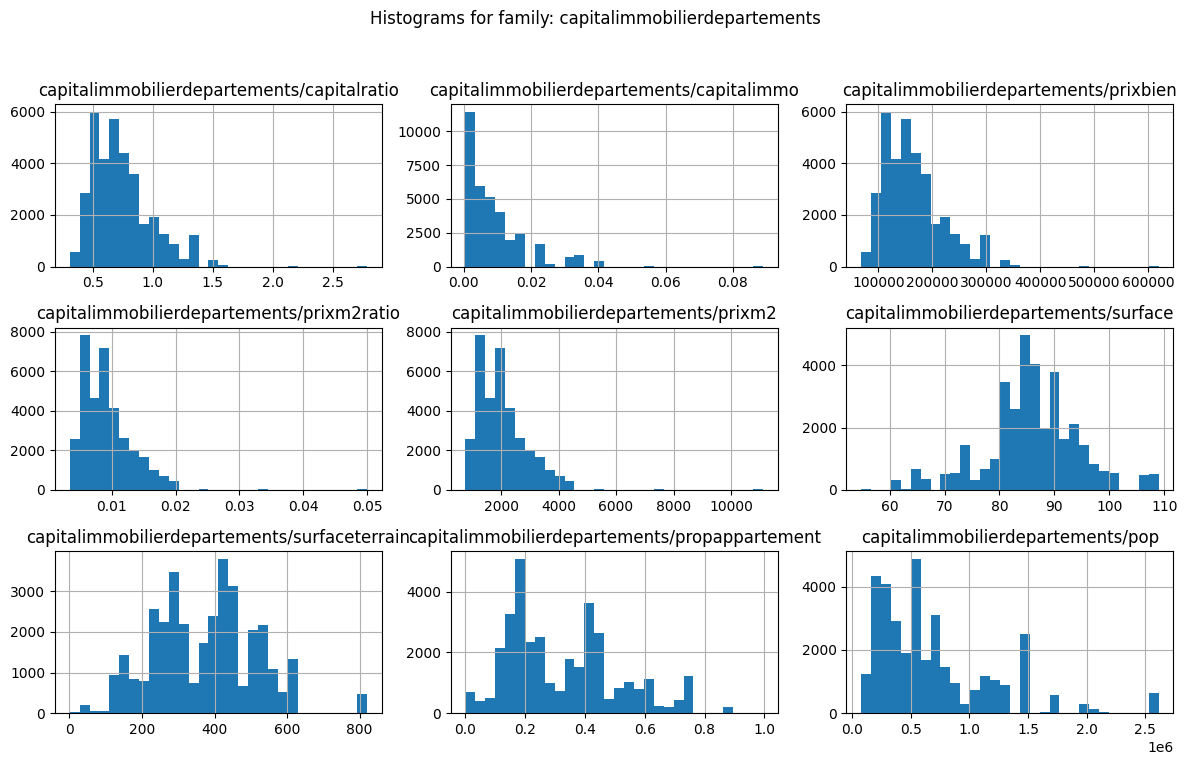

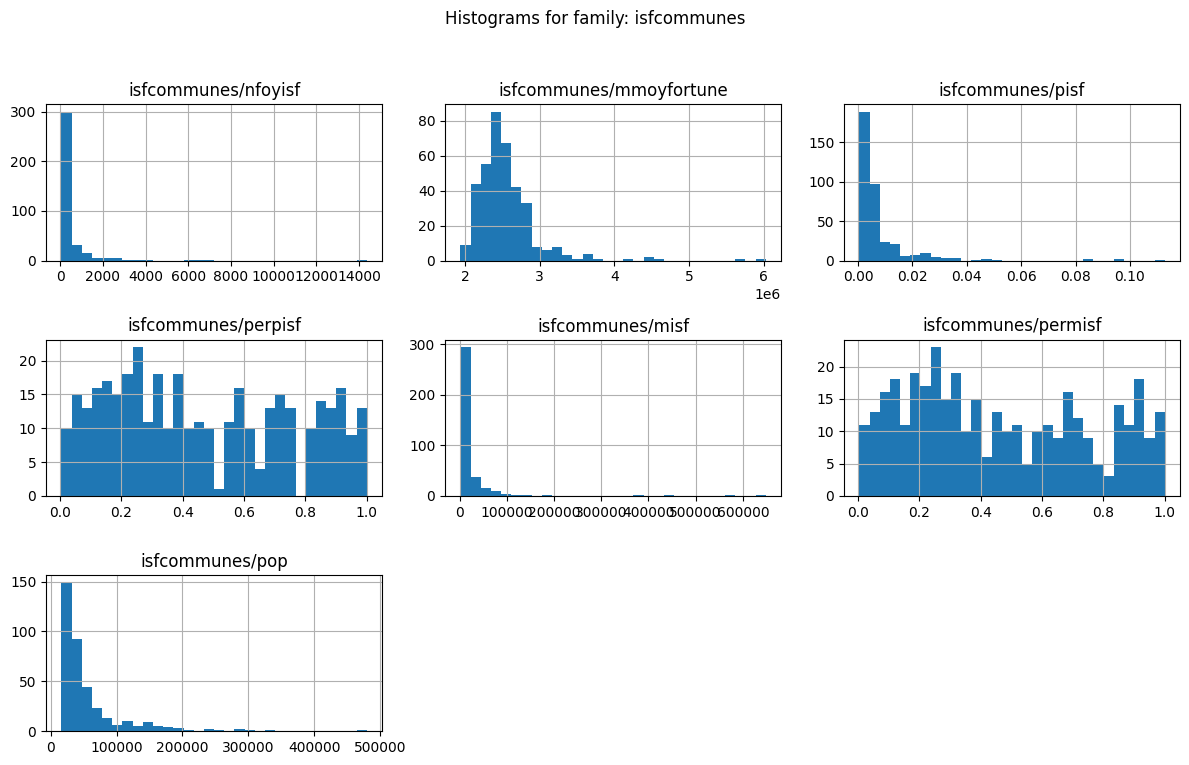

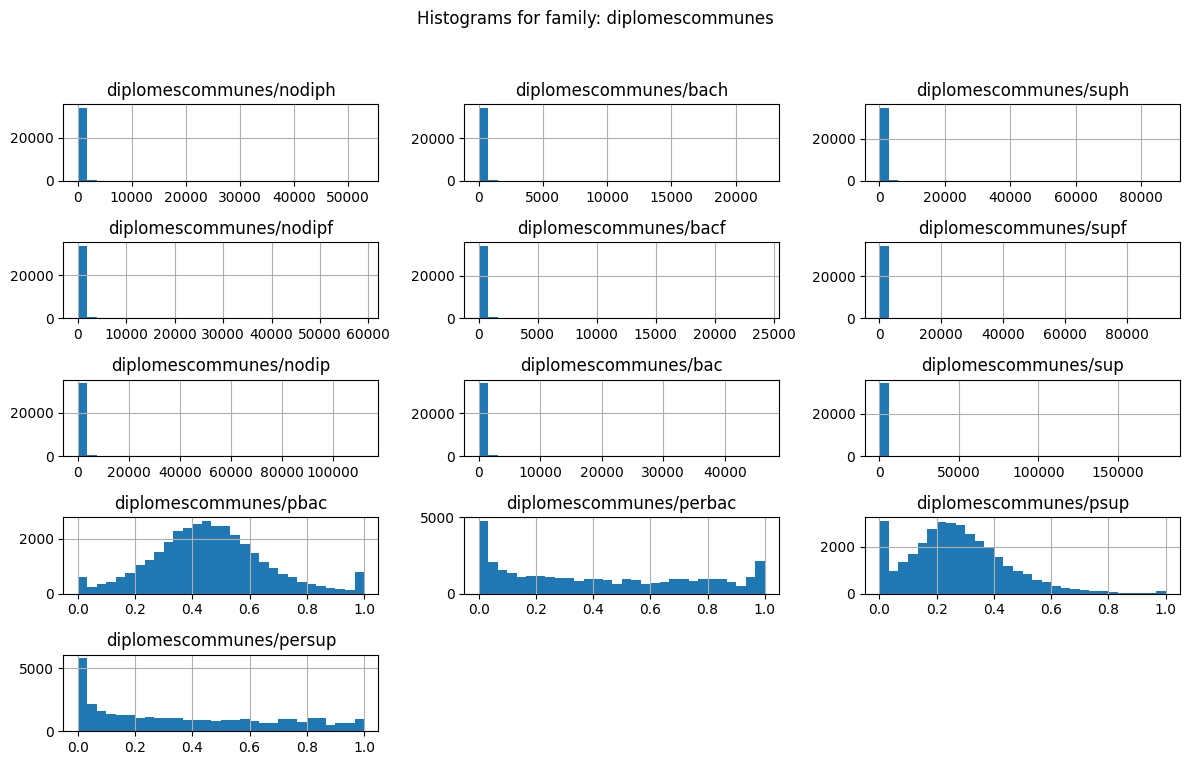

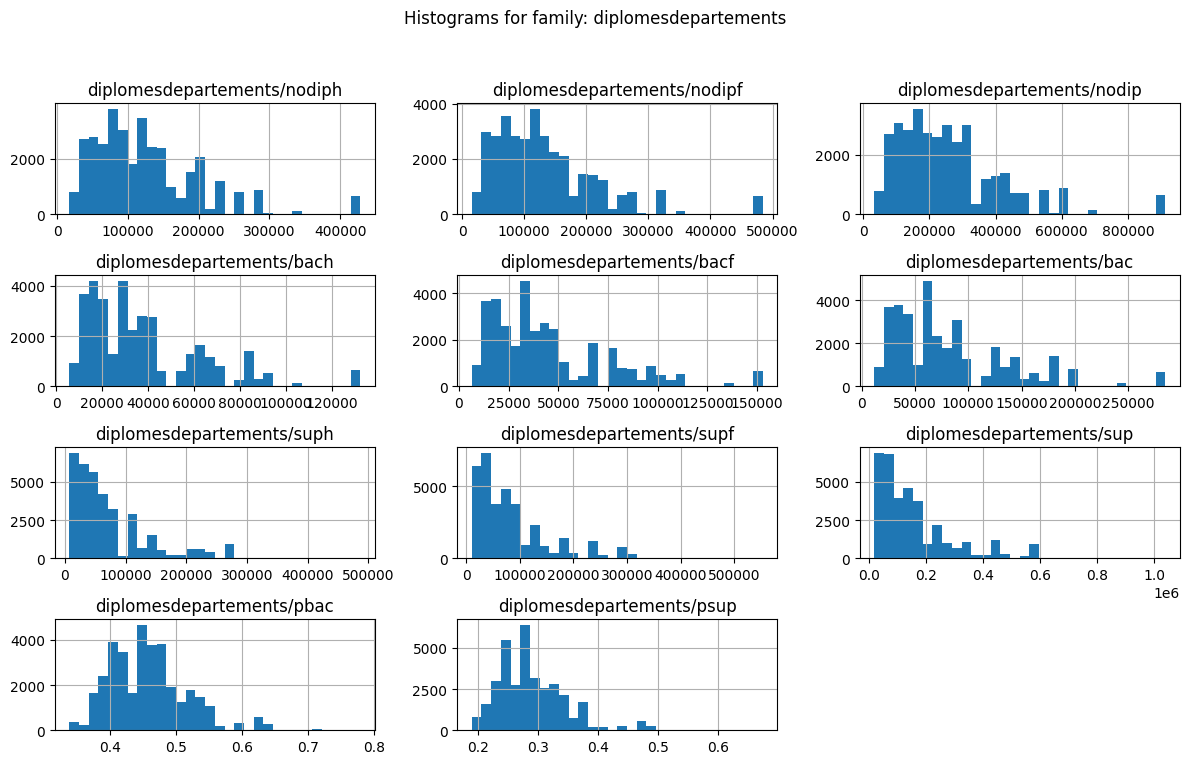

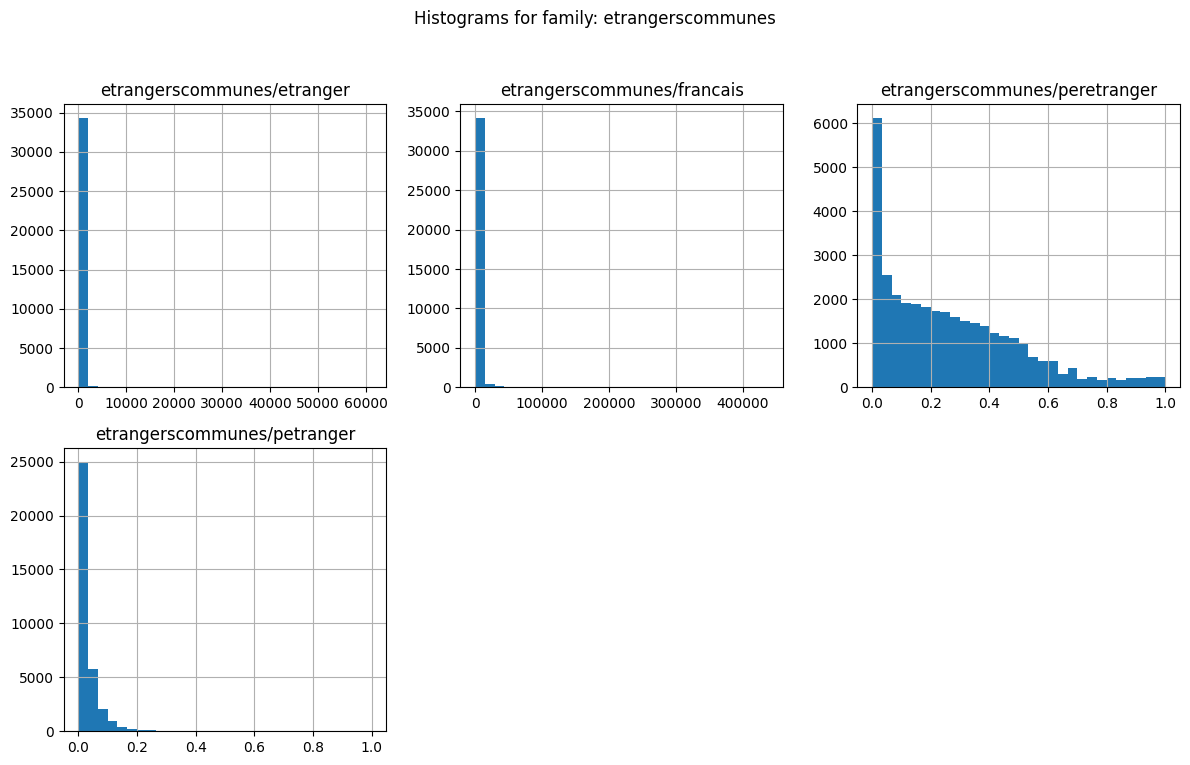

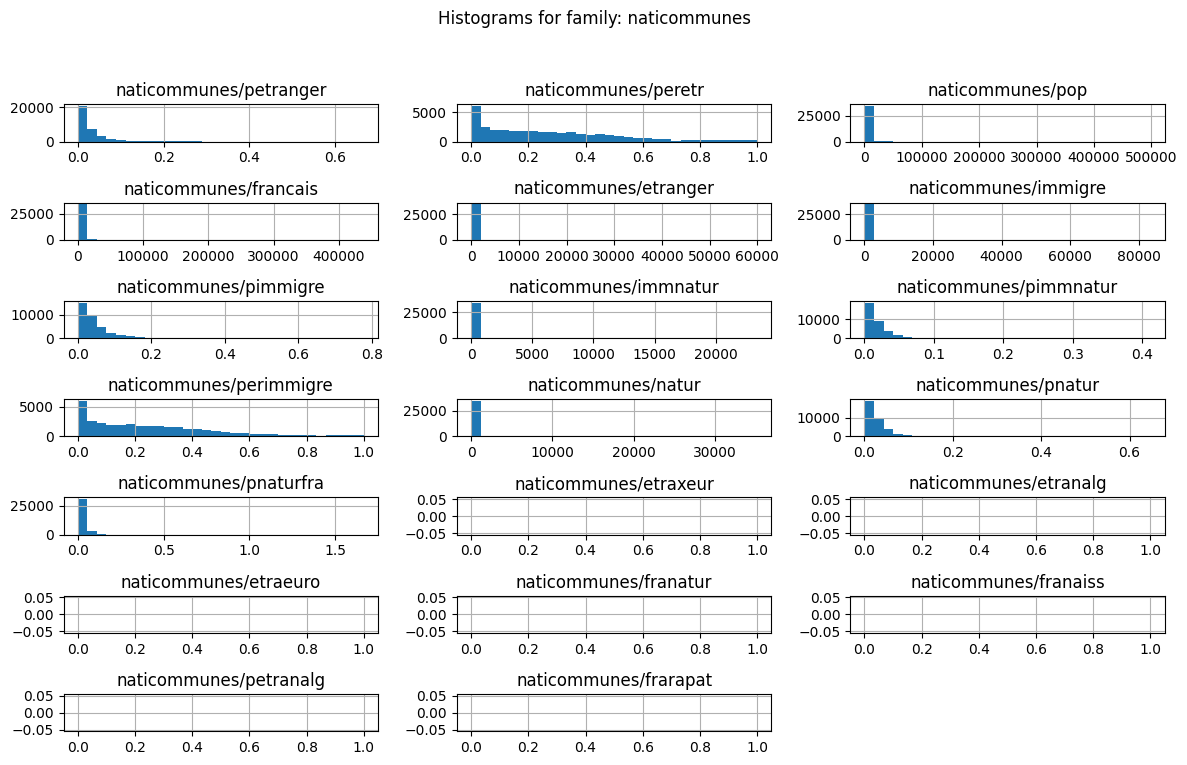

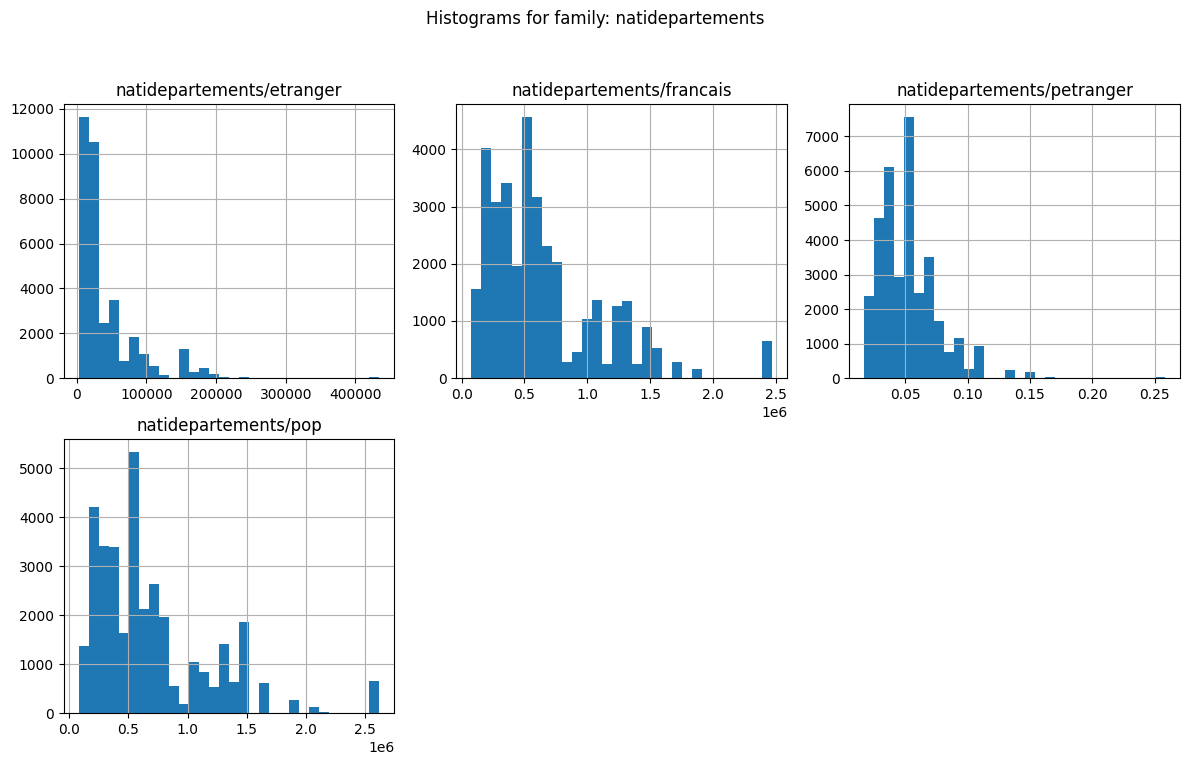

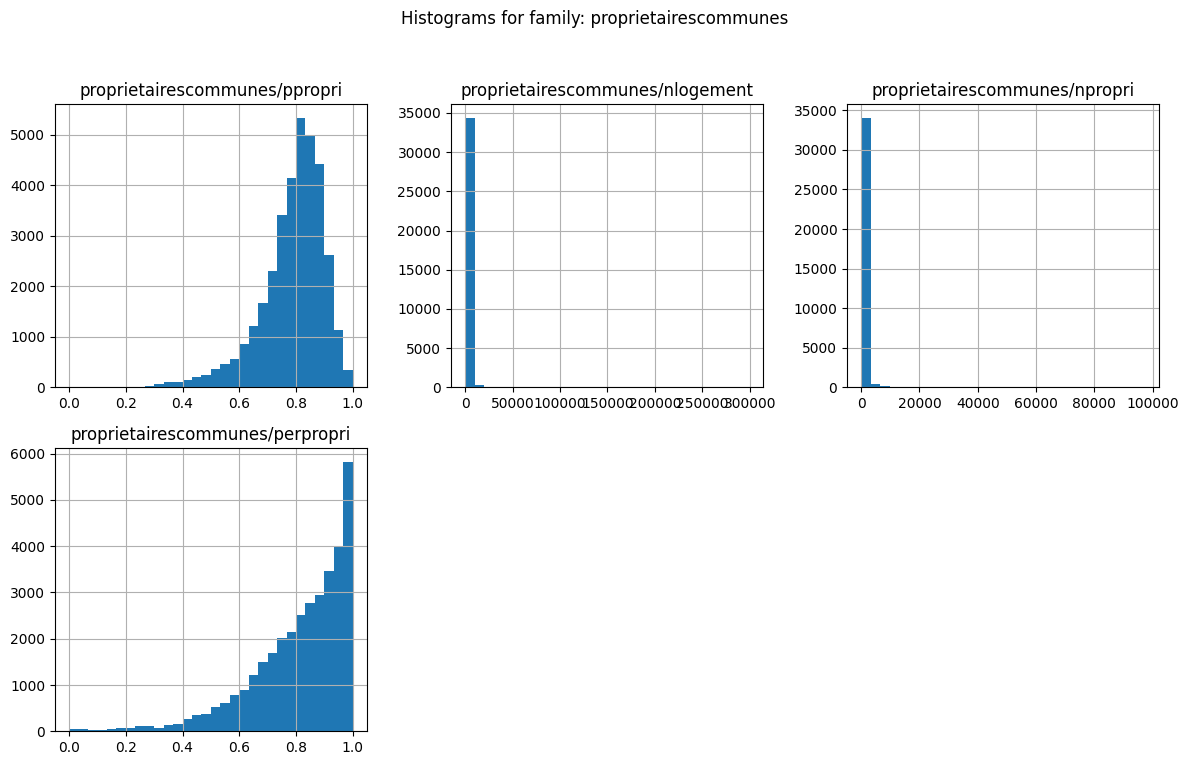

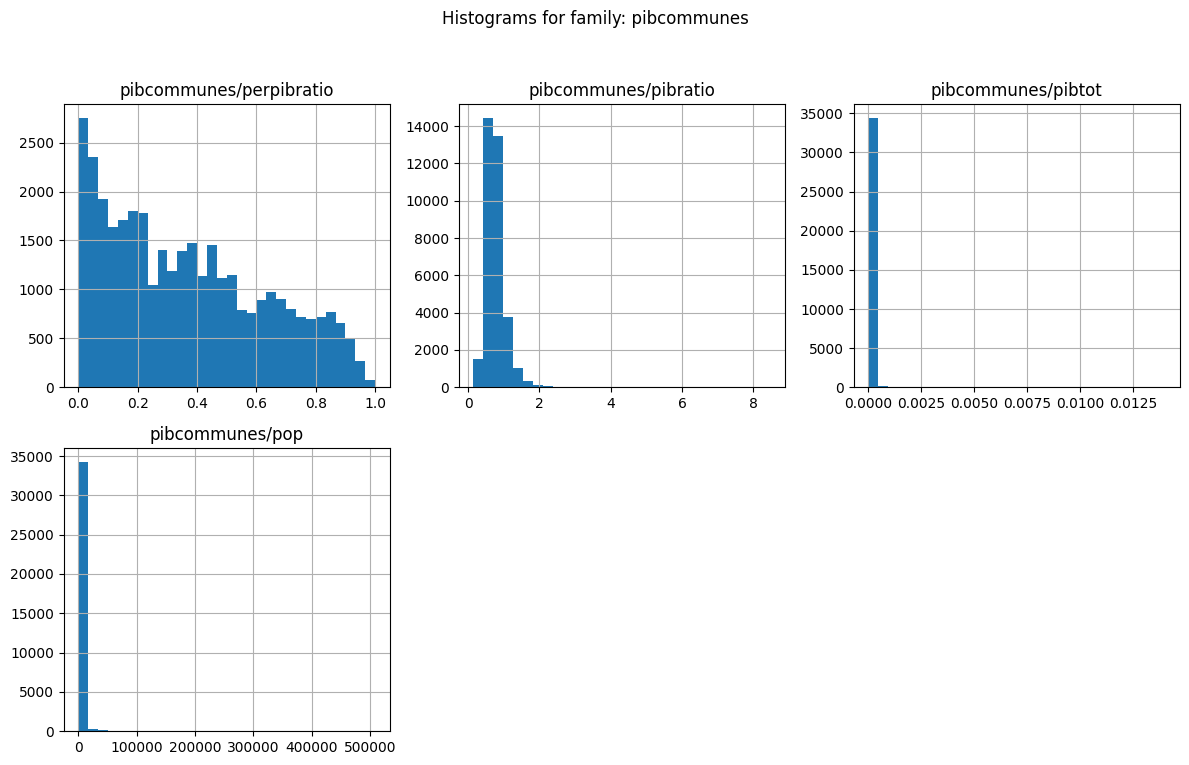

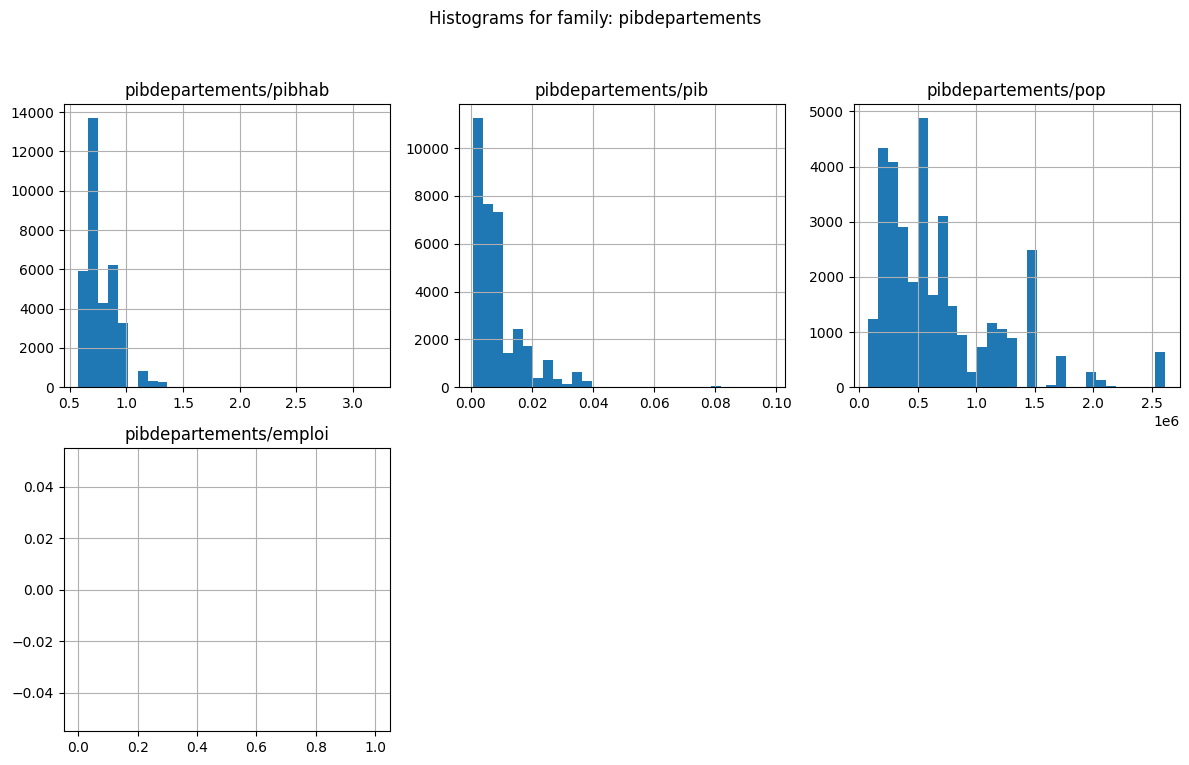

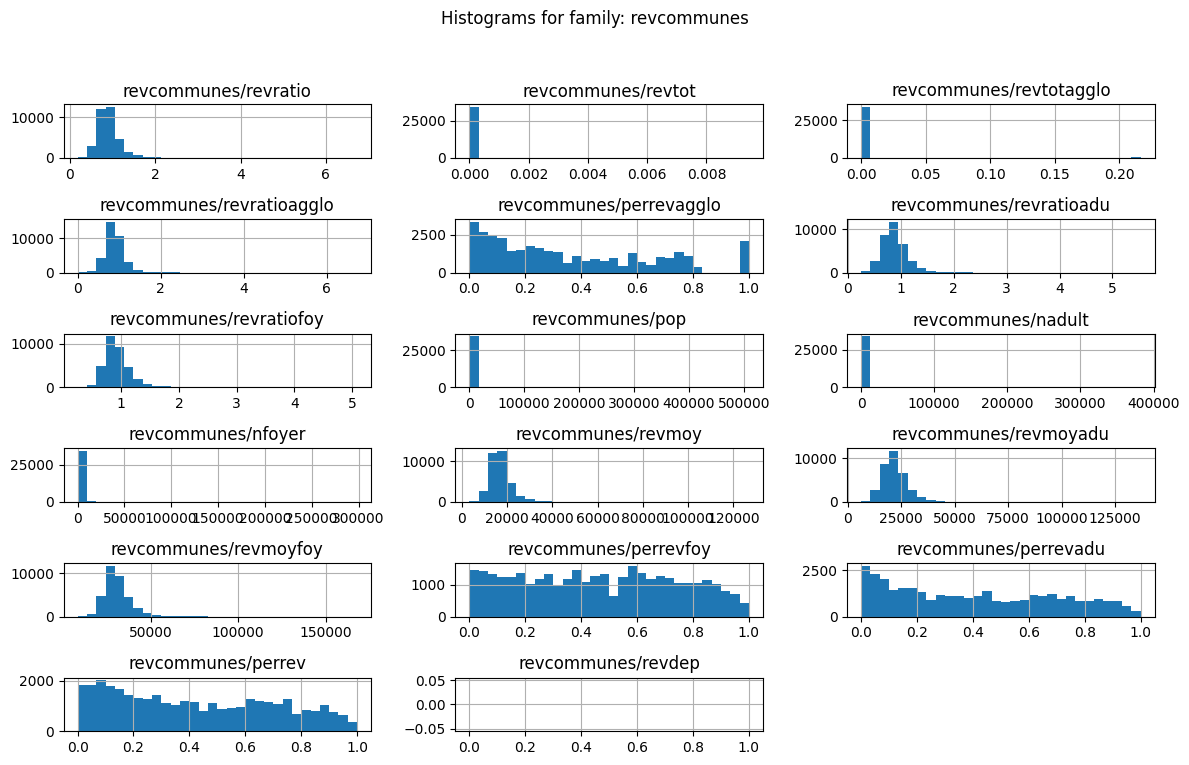

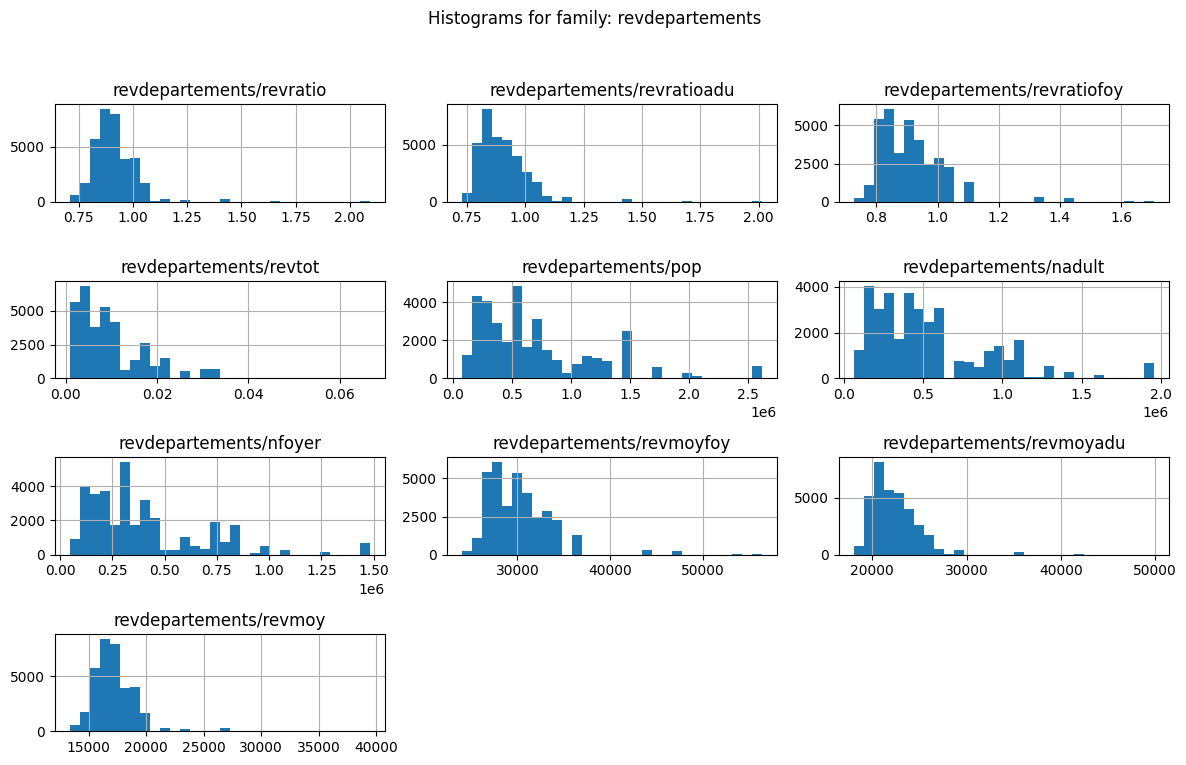

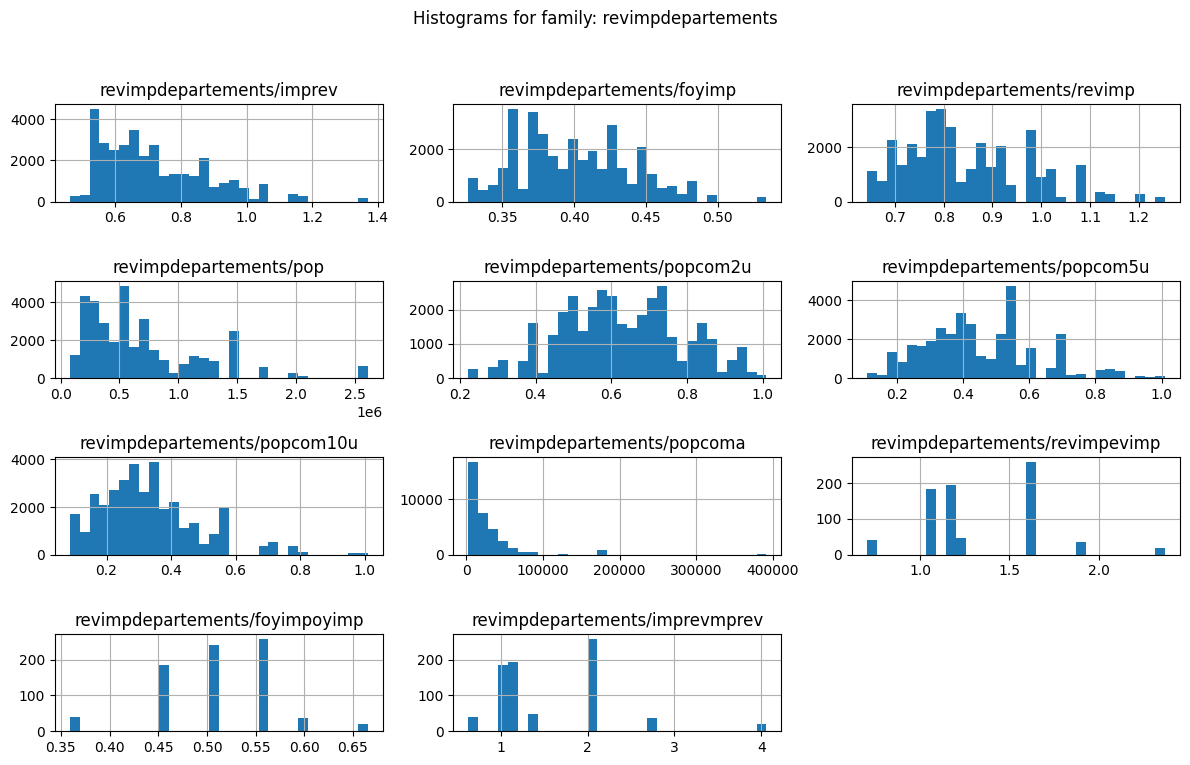

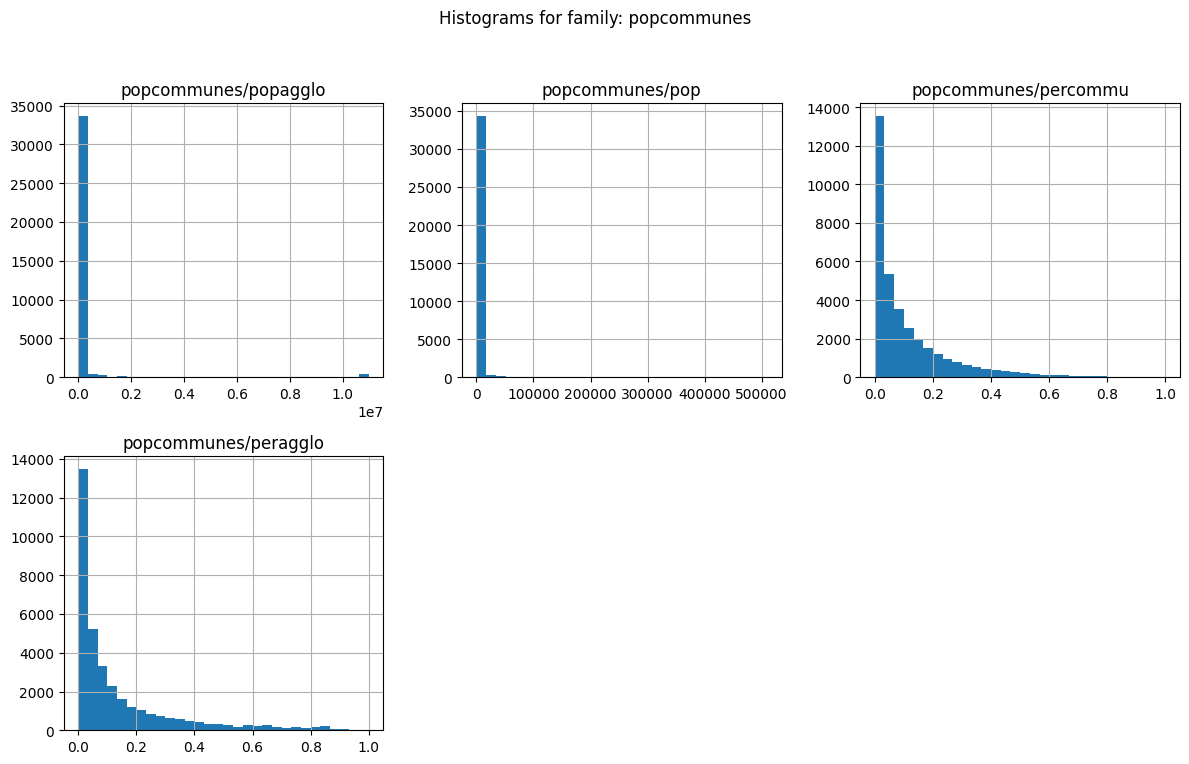

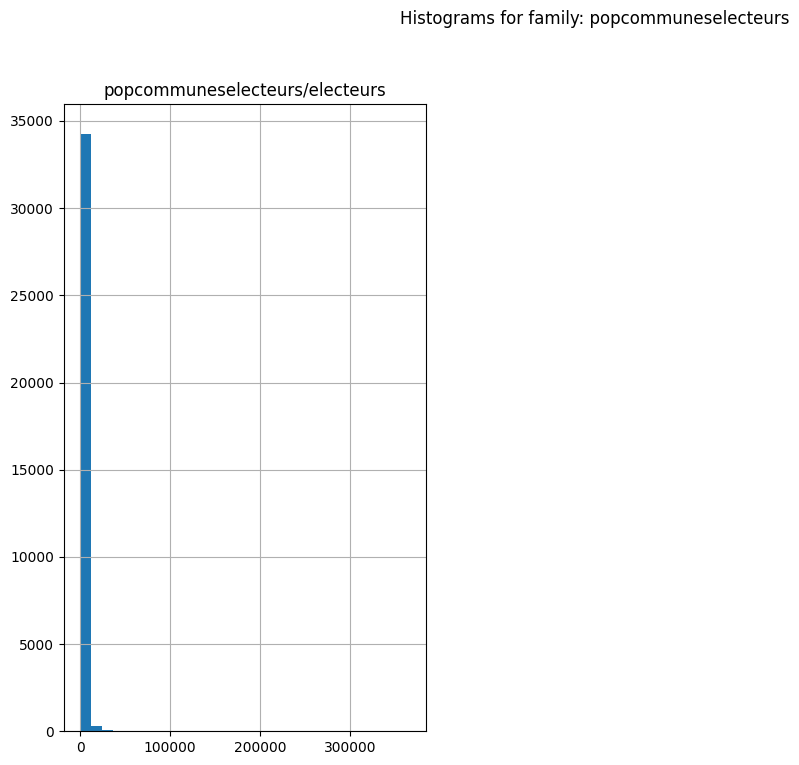

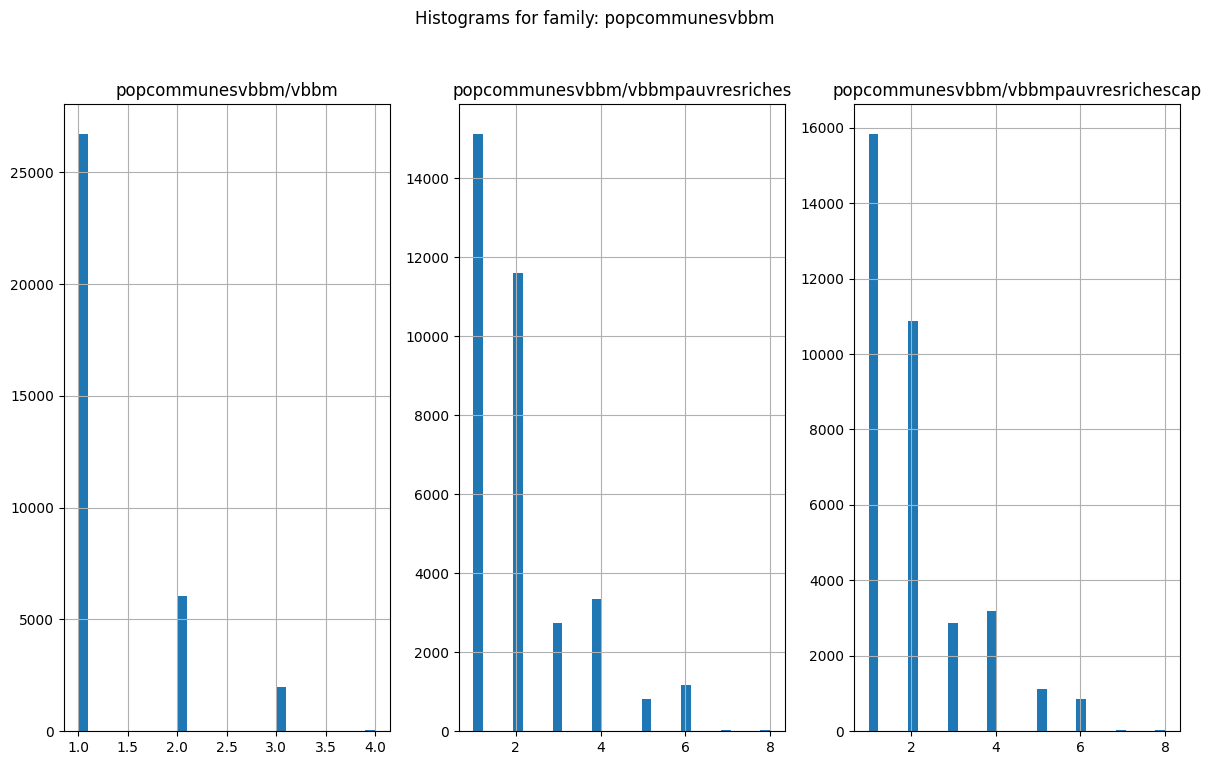

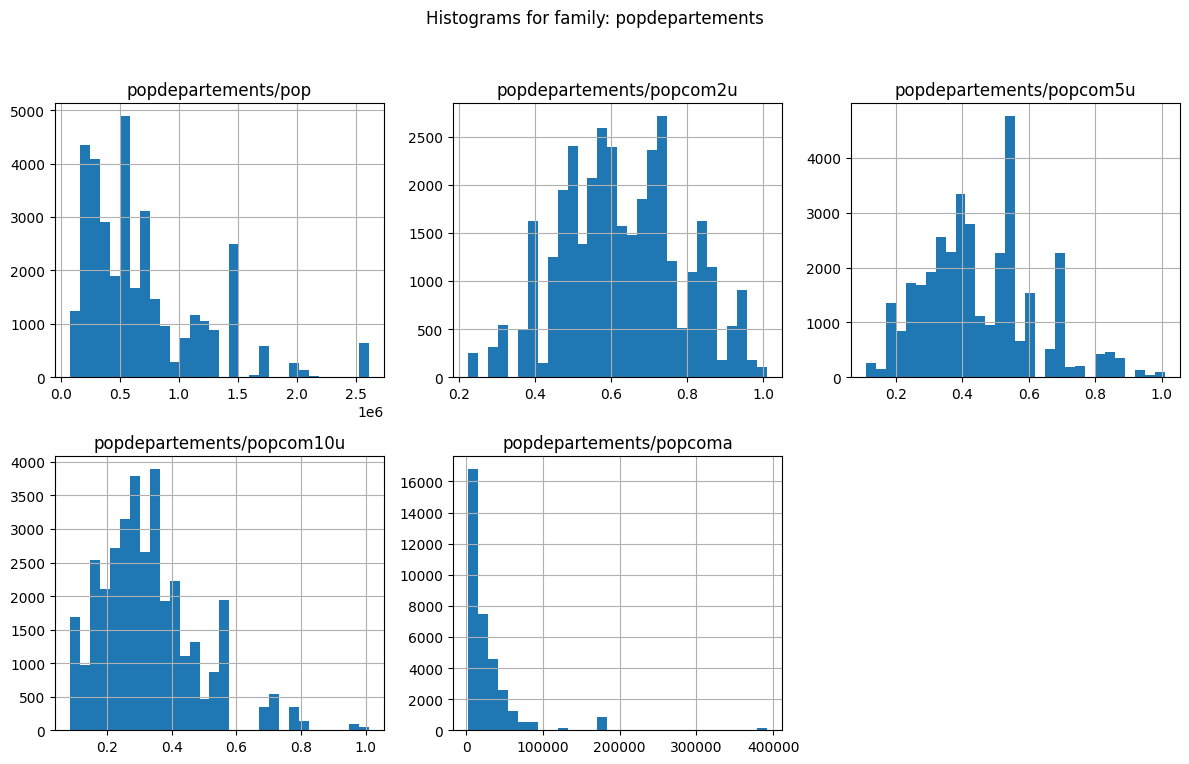

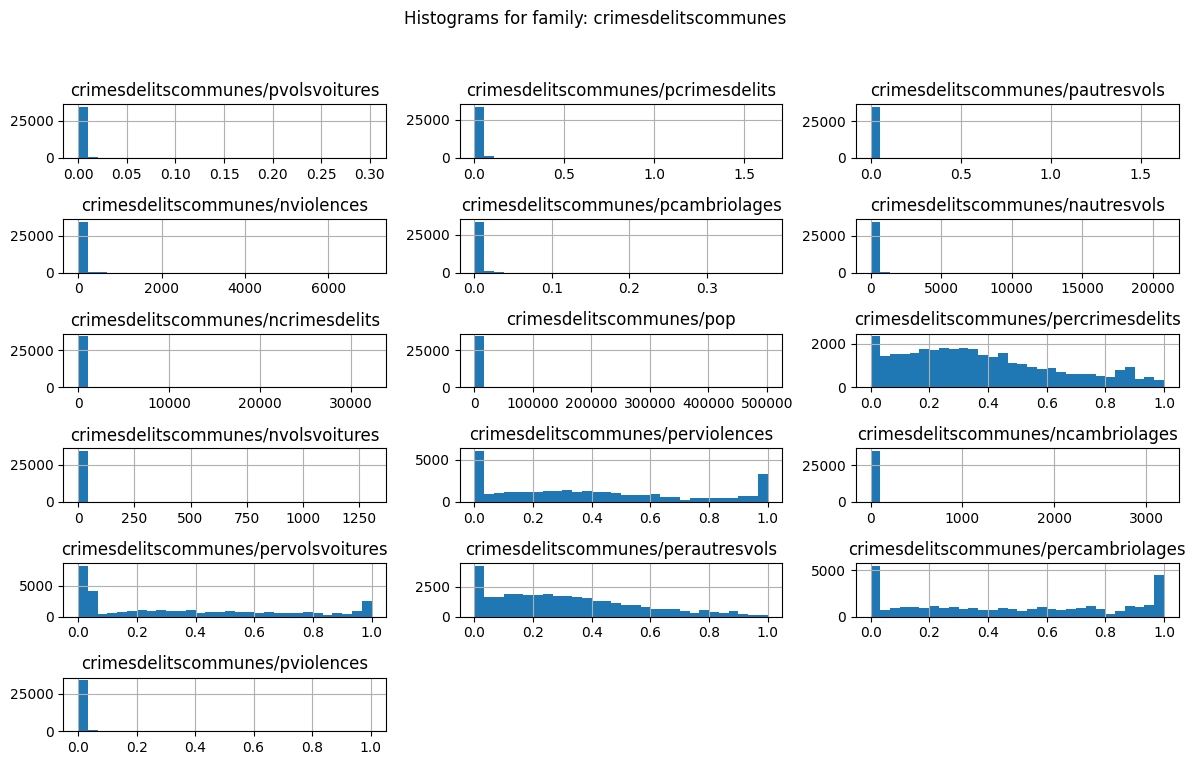

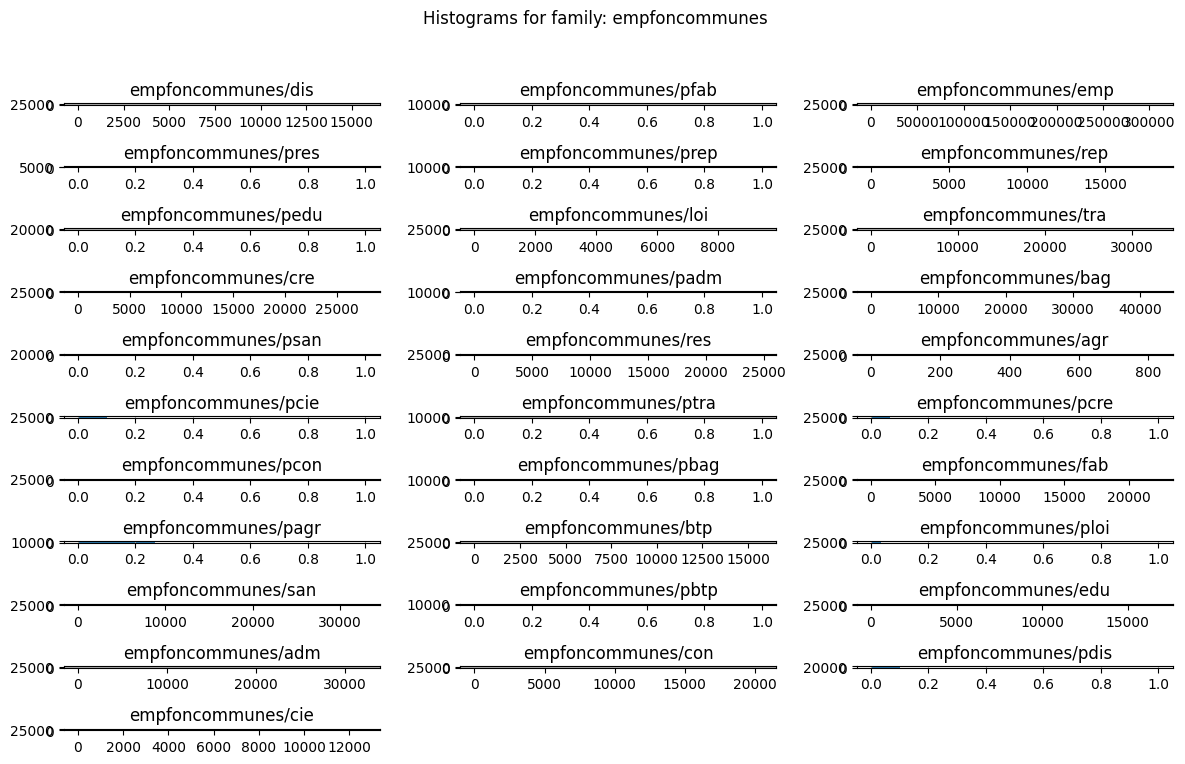

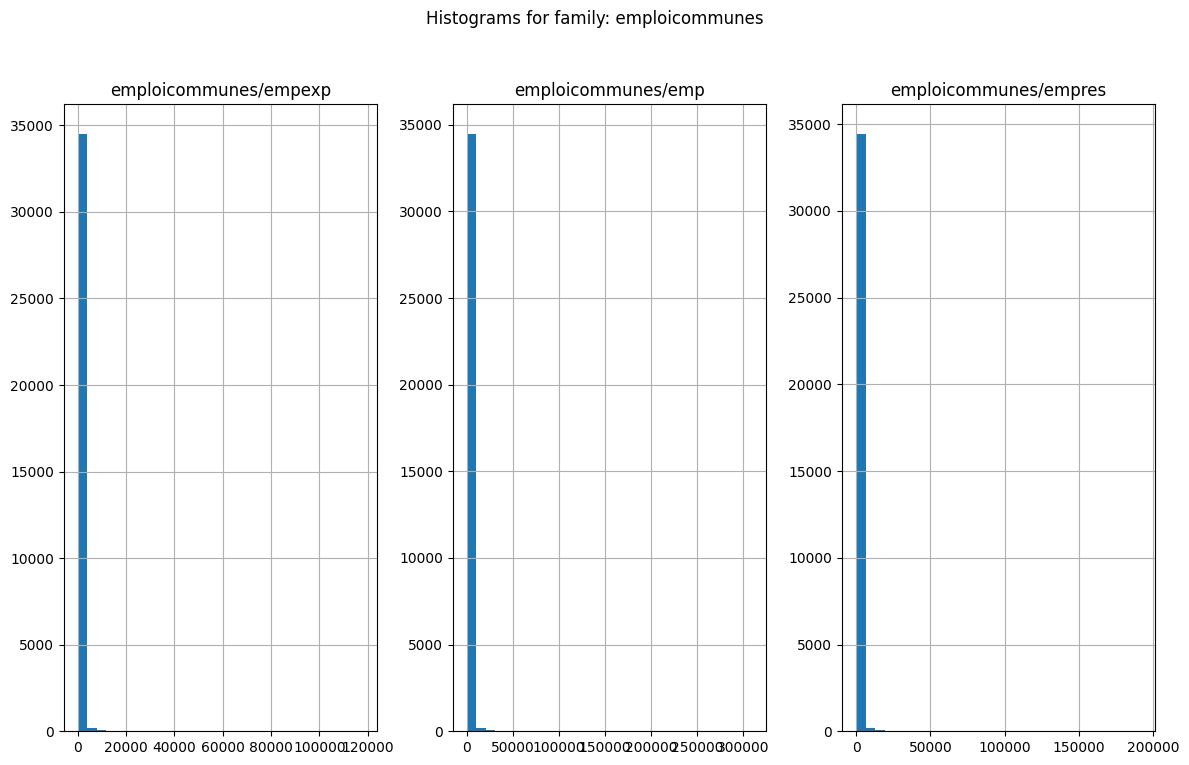

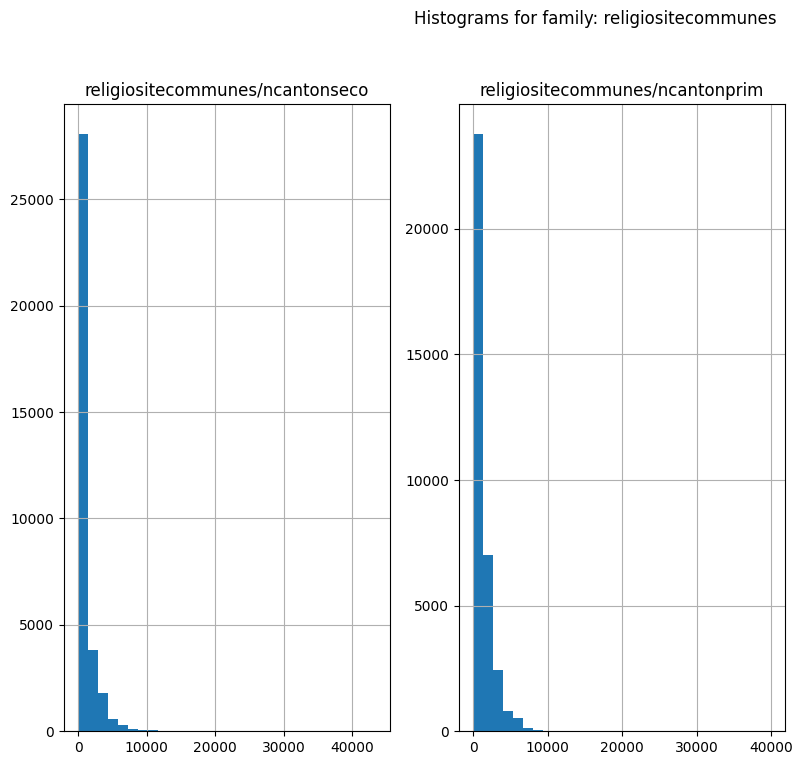

/tmp/ipykernel_2295/1155977053.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


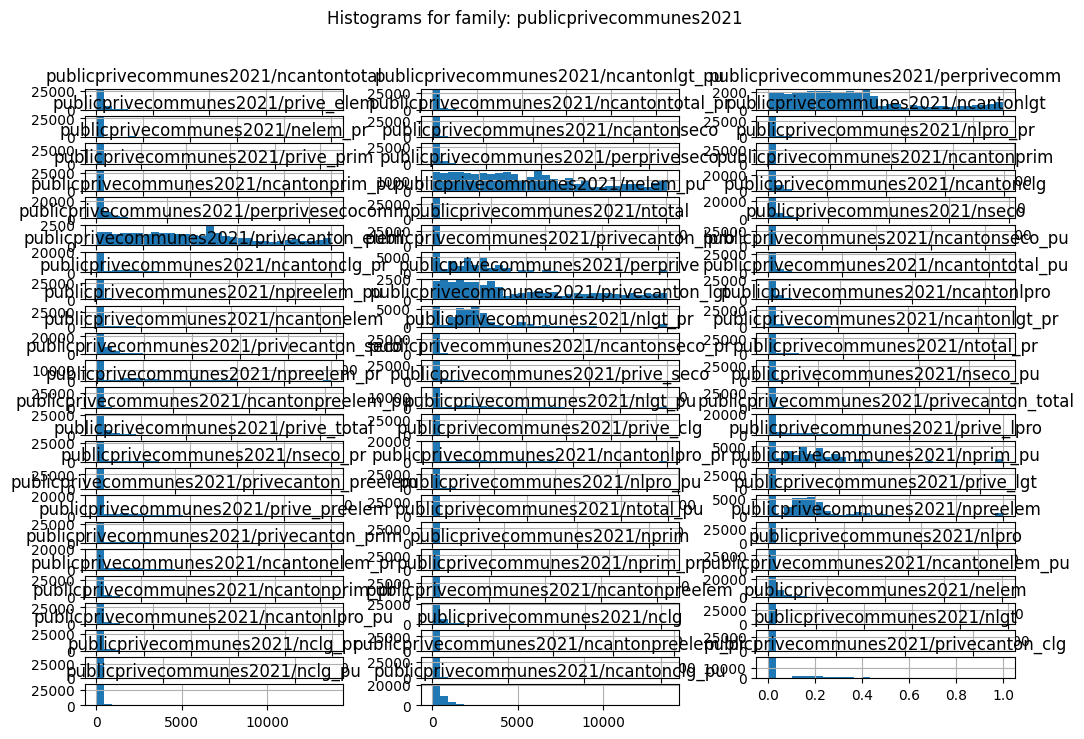

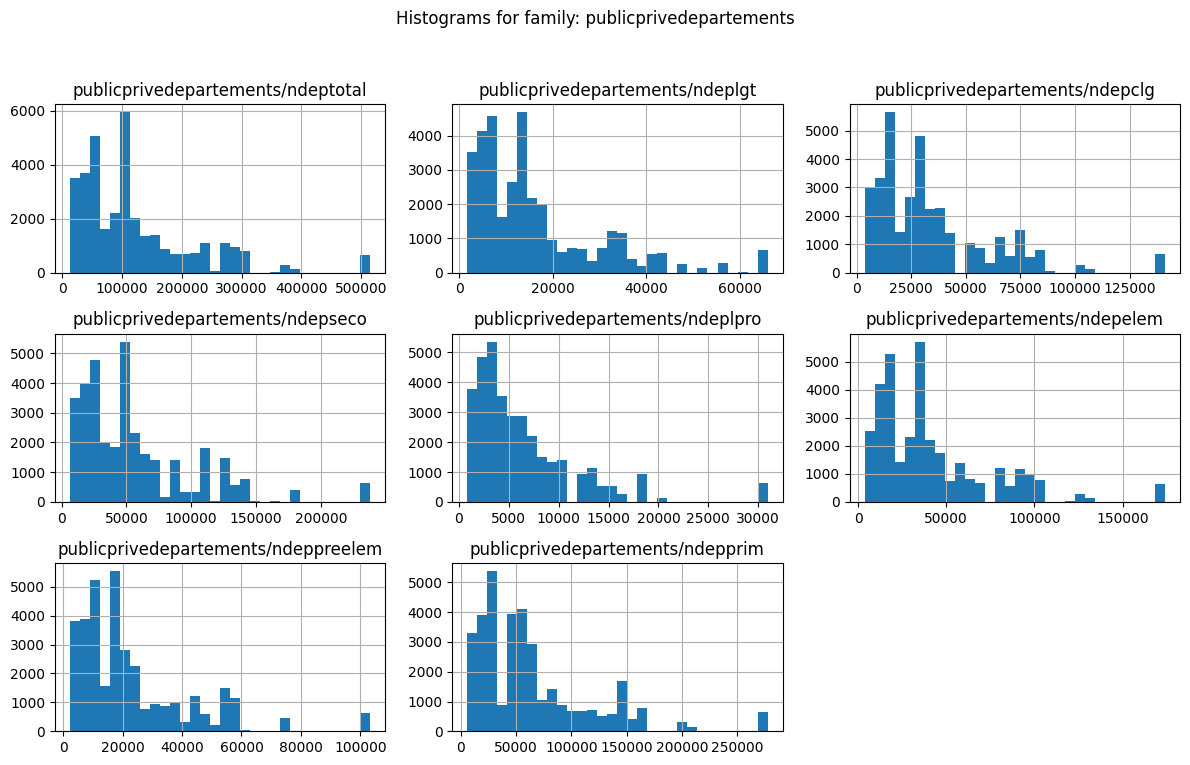

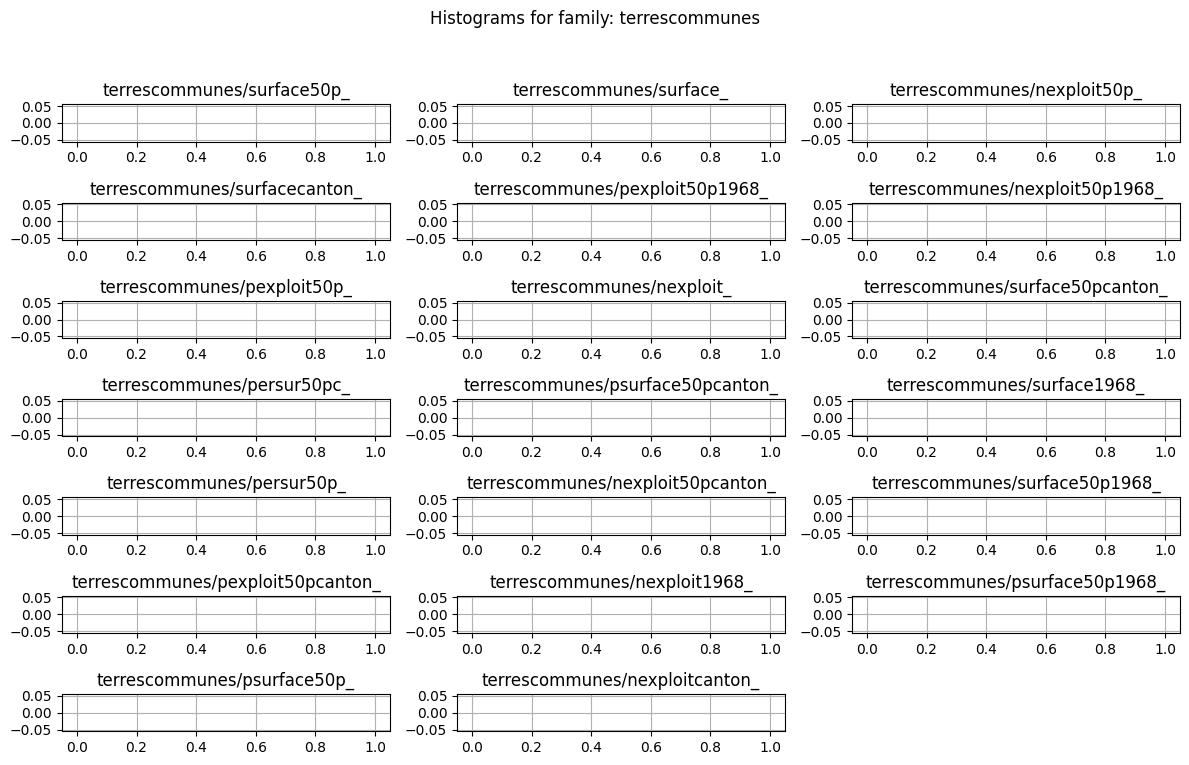

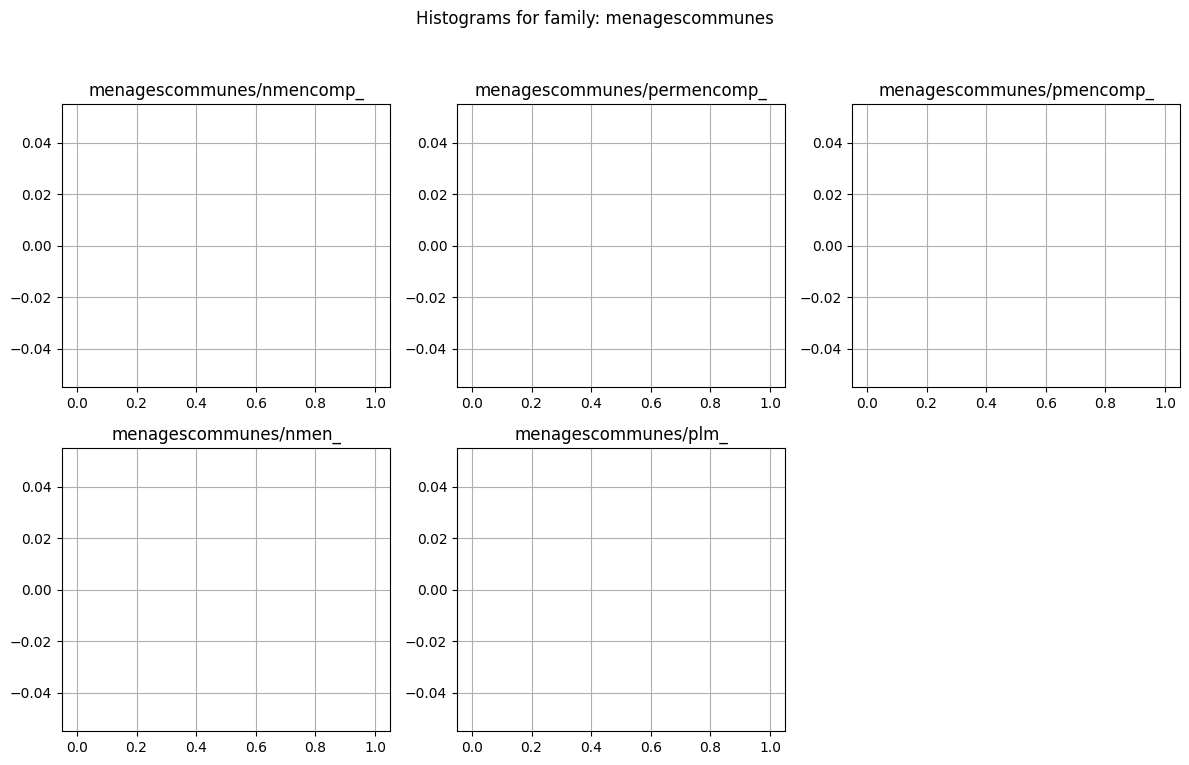

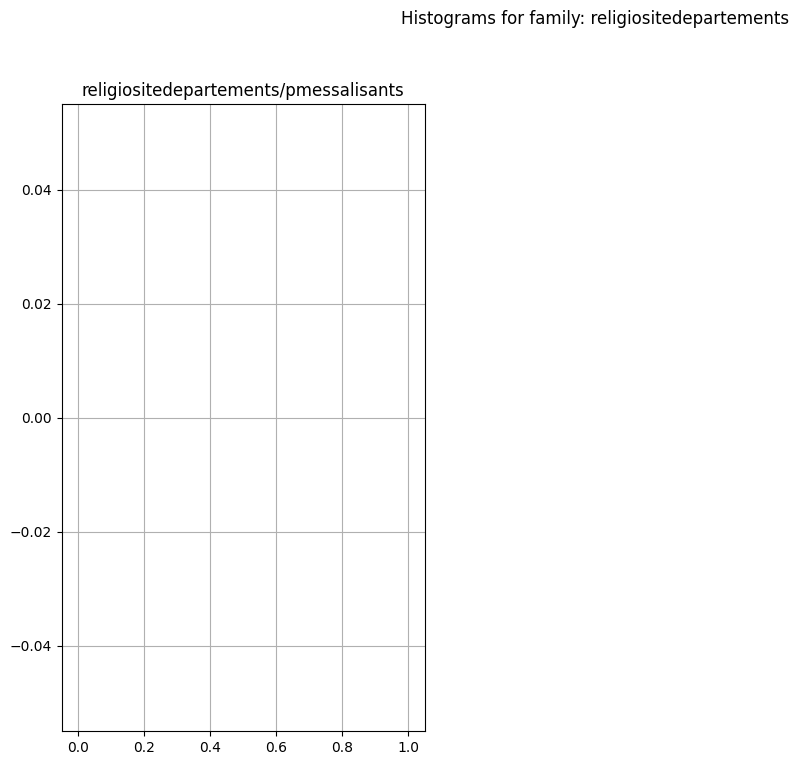

In [42]:
# Plot histogram for each family
for family, cols in family_dict.items():
    cols_ = list(set(cols)- set(nan_cols))
    X[cols].hist(figsize=(12, 8), bins=30, layout=(-1, 3), sharex=False, sharey=False)
    plt.suptitle(f'Histograms for family: {family}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
n_th = 36529
n = X['codecommune'].nunique()
print(n) 
print(f"{(n*100/n_th):1f}%")
print(X['dep'].nunique()) # France metropolitaine 


34849
95.400914%
96


In [ ]:
N = dataset.isnull().mean(axis=0)

In [ ]:
N

codecommune                    0.000000
inscrits                       0.000000
pvoteppar                      0.000000
pvotepvoteG                    0.000000
pvotepvoteC                    0.000000
                                 ...   
menagescommunes/nmen_          0.957786
menagescommunes/permencomp_    0.957786
menagescommunes/pmencomp_      0.957786
menagescommunes/nmencomp_      0.957786
menagescommunes/plm_           0.957786
Length: 1104, dtype: float64

In [ ]:
import matplotlib.pyplot as plt

<Axes: >

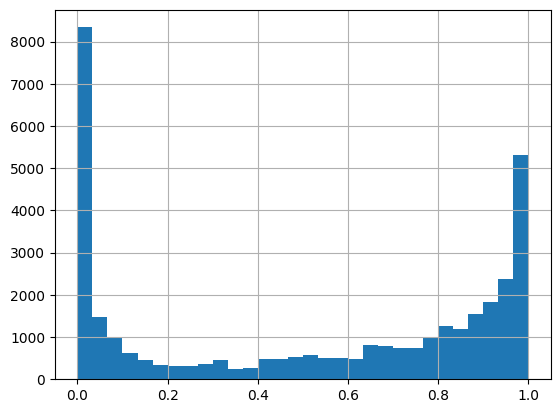

In [ ]:
dataset[dataset['annee']==2017]['cspcommunes/perindp'].hist(bins=30)

In [ ]:
dataset.columns.to_list()

['codecommune',
 'inscrits',
 'pvoteppar',
 'pvotepvoteG',
 'pvotepvoteC',
 'pvotepvoteD',
 'pvotepvoteCG',
 'pvotepvoteCD',
 'pvotepreviousppar',
 'pvotepreviouspreviousppar',
 'pvotepreviouspvoteG',
 'pvotepreviouspreviouspvoteG',
 'pvotepreviouspvoteC',
 'pvotepreviouspreviouspvoteC',
 'pvotepreviouspvoteD',
 'pvotepreviouspreviouspvoteD',
 'pvotepreviouspvoteCG',
 'pvotepreviouspreviouspvoteCG',
 'pvotepreviouspvoteCD',
 'pvotepreviouspreviouspvoteCD',
 'dep',
 'agesexcommunes/popf014',
 'agesexcommunes/popf1539',
 'agesexcommunes/popf4059',
 'agesexcommunes/popf60p',
 'agesexcommunes/poph014',
 'agesexcommunes/poph1539',
 'agesexcommunes/poph4059',
 'agesexcommunes/poph60p',
 'agesexcommunes/agef',
 'agesexcommunes/ageh',
 'agesexcommunes/popf',
 'agesexcommunes/poph',
 'agesexcommunes/propf',
 'agesexcommunes/age',
 'agesexcommunes/pop',
 'agesexcommunes/propf014',
 'agesexcommunes/propf1539',
 'agesexcommunes/propf4059',
 'agesexcommunes/propf60p',
 'agesexcommunes/prop014',
 'a

In [ ]:
dataset[['annee', 'cspcommunes/perindp']].dropna()['annee'].unique()

array([2017, 1988, 2022, 1995, 2027, 1965, 1969, 2002, 1974, 2007, 2012,
       1981])

In [ ]:
N[N<0.2].to_frame().T.columns.to_list()

['codecommune',
 'inscrits',
 'pvoteppar',
 'pvotepvoteG',
 'pvotepvoteC',
 'pvotepvoteD',
 'pvotepvoteCG',
 'pvotepvoteCD',
 'pvotepreviousppar',
 'pvotepreviouspreviousppar',
 'pvotepreviouspvoteG',
 'pvotepreviouspreviouspvoteG',
 'pvotepreviouspvoteC',
 'pvotepreviouspreviouspvoteC',
 'pvotepreviouspvoteD',
 'pvotepreviouspreviouspvoteD',
 'pvotepreviouspvoteCG',
 'pvotepreviouspreviouspvoteCG',
 'pvotepreviouspvoteCD',
 'pvotepreviouspreviouspvoteCD',
 'dep',
 'agesexcommunes/popf014',
 'agesexcommunes/popf1539',
 'agesexcommunes/popf4059',
 'agesexcommunes/popf60p',
 'agesexcommunes/poph014',
 'agesexcommunes/poph1539',
 'agesexcommunes/poph4059',
 'agesexcommunes/poph60p',
 'agesexcommunes/agef',
 'agesexcommunes/ageh',
 'agesexcommunes/popf',
 'agesexcommunes/poph',
 'agesexcommunes/propf',
 'agesexcommunes/age',
 'agesexcommunes/pop',
 'agesexcommunes/propf014',
 'agesexcommunes/propf1539',
 'agesexcommunes/propf4059',
 'agesexcommunes/propf60p',
 'agesexcommunes/prop014',
 'a

In [ ]:
import numpy as np
import pandas as pd
data = np.load('../../data/raw/geo_data/distance_cities/distance_matrix.npz')

In [ ]:
m = pd.read_parquet('../../data/raw/geo_data/distance_cities/mapping.parquet')

In [ ]:
m[m.iloc[:,0]=="05039"].index[0]

np.int64(1)

{'03252': 0,
 '05039': 1,
 '16203': 2,
 '16372': 3,
 '24002': 4,
 '24011': 5,
 '24026': 6,
 '24098': 7,
 '24102': 8,
 '24108': 9,
 '24115': 10,
 '24135': 11,
 '24138': 12,
 '24139': 13,
 '24175': 14,
 '24208': 15,
 '24256': 16,
 '24263': 17,
 '24312': 18,
 '24313': 19,
 '24326': 20,
 '24330': 21,
 '24337': 22,
 '24426': 23,
 '24431': 24,
 '24443': 25,
 '24540': 26,
 '24557': 27,
 '27447': 28,
 '31166': 29,
 '36006': 30,
 '36012': 31,
 '36014': 32,
 '36032': 33,
 '36033': 34,
 '36042': 35,
 '36048': 36,
 '36062': 37,
 '36069': 38,
 '36072': 39,
 '36077': 40,
 '36080': 41,
 '36081': 42,
 '36082': 43,
 '36086': 44,
 '36090': 45,
 '36092': 46,
 '36103': 47,
 '36107': 48,
 '36117': 49,
 '36131': 50,
 '36154': 51,
 '36155': 52,
 '36158': 53,
 '36160': 54,
 '36161': 55,
 '36166': 56,
 '36192': 57,
 '36200': 58,
 '36216': 59,
 '36219': 60,
 '36228': 61,
 '36233': 62,
 '36235': 63,
 '36237': 64,
 '36243': 65,
 '36244': 66,
 '37003': 67,
 '37074': 68,
 '37138': 69,
 '37252': 70,
 '41002': 71,
 '

In [ ]:
array1 = data['array']

In [ ]:
array1

array([341.8 , 321.  , 317.8 , ...,  34.88, 576.  , 601.5 ],
      shape=(620488378,), dtype=float16)

In [ ]:
class ComposeDistanceMatrix:

    def __init__(self):
        self.distance_array = None
        self.i = None
        self.j = None
        self.N = None
    
    def _load_files(self):
        distance_npz = np.load('../../data/raw/geo_data/distance_cities/distance_matrix.npz')
        self.distance_array = distance_npz['array']

        i_npz =  np.load('../../data/raw/geo_data/distance_cities/i.npz')['arr_0']
        self.i = i_npz

        j_npz =  np.load('../../data/raw/geo_data/distance_cities/j.npz')['arr_0']
        self.j = j_npz

        m = pd.read_parquet('../../data/raw/geo_data/distance_cities/mapping.parquet')
        self.mapping = {value: idx for idx, value in m.iloc[:, 0].items()}

        self.N = len(i)

    def w(alpha, beta):
        pass

In [ ]:
dm = ComposeDistanceMatrix()
dm._load_files()

BadZipFile: Overlapped entries: 'arr_0.npy' (possible zip bomb)

In [ ]:
import pandas as pd

In [ ]:
X = pd.read_parquet('../../data/polls/2022/polls_t1.parquet')

In [ ]:
X[['C', 'CD', 'CG', 'G', 'D']].mean()

C     26.022875
CD     6.643950
CG    10.060875
G     15.054275
D     28.539950
dtype: float64